(sec:modello-normale)=
# Il modello normale

Fissato $p \in [0, 1]$, per ogni $n \in \mathbb N$ sia
$X_n \sim \mathrm B(n, p)$. In altre parole, $X_n$ è una variabile aleatoria
distribuita secondo una legge binomiale di parametri $n$ e $p$, che descrive
il numero di successi ottenuti in $n$ ripetizioni indipendenti di un
esperimento di Bernoulli di parametro $p$. Supponiamo di aumentare via via
$n$, per capire se abbia senso ragionare in termini di una distribuzione
limite di $X_n$. È evidente fin da subito che questo non può succedere, in
quanto $\mathbb E(X_n) = np$ e $\mathrm{Var}(X_n) = np(1-p)$ e dunque, man mano
che $n$ aumenta, da una parte il centro della distribuzione si allontana
sempre di più dall'origine e dall'altra la varianza aumenta, come si può
facilmente verificare osservando i grafici delle funzioni di massa di
probabilità visualizzati nella {numref}`Figura %s <fig:binomial-divergence>`.

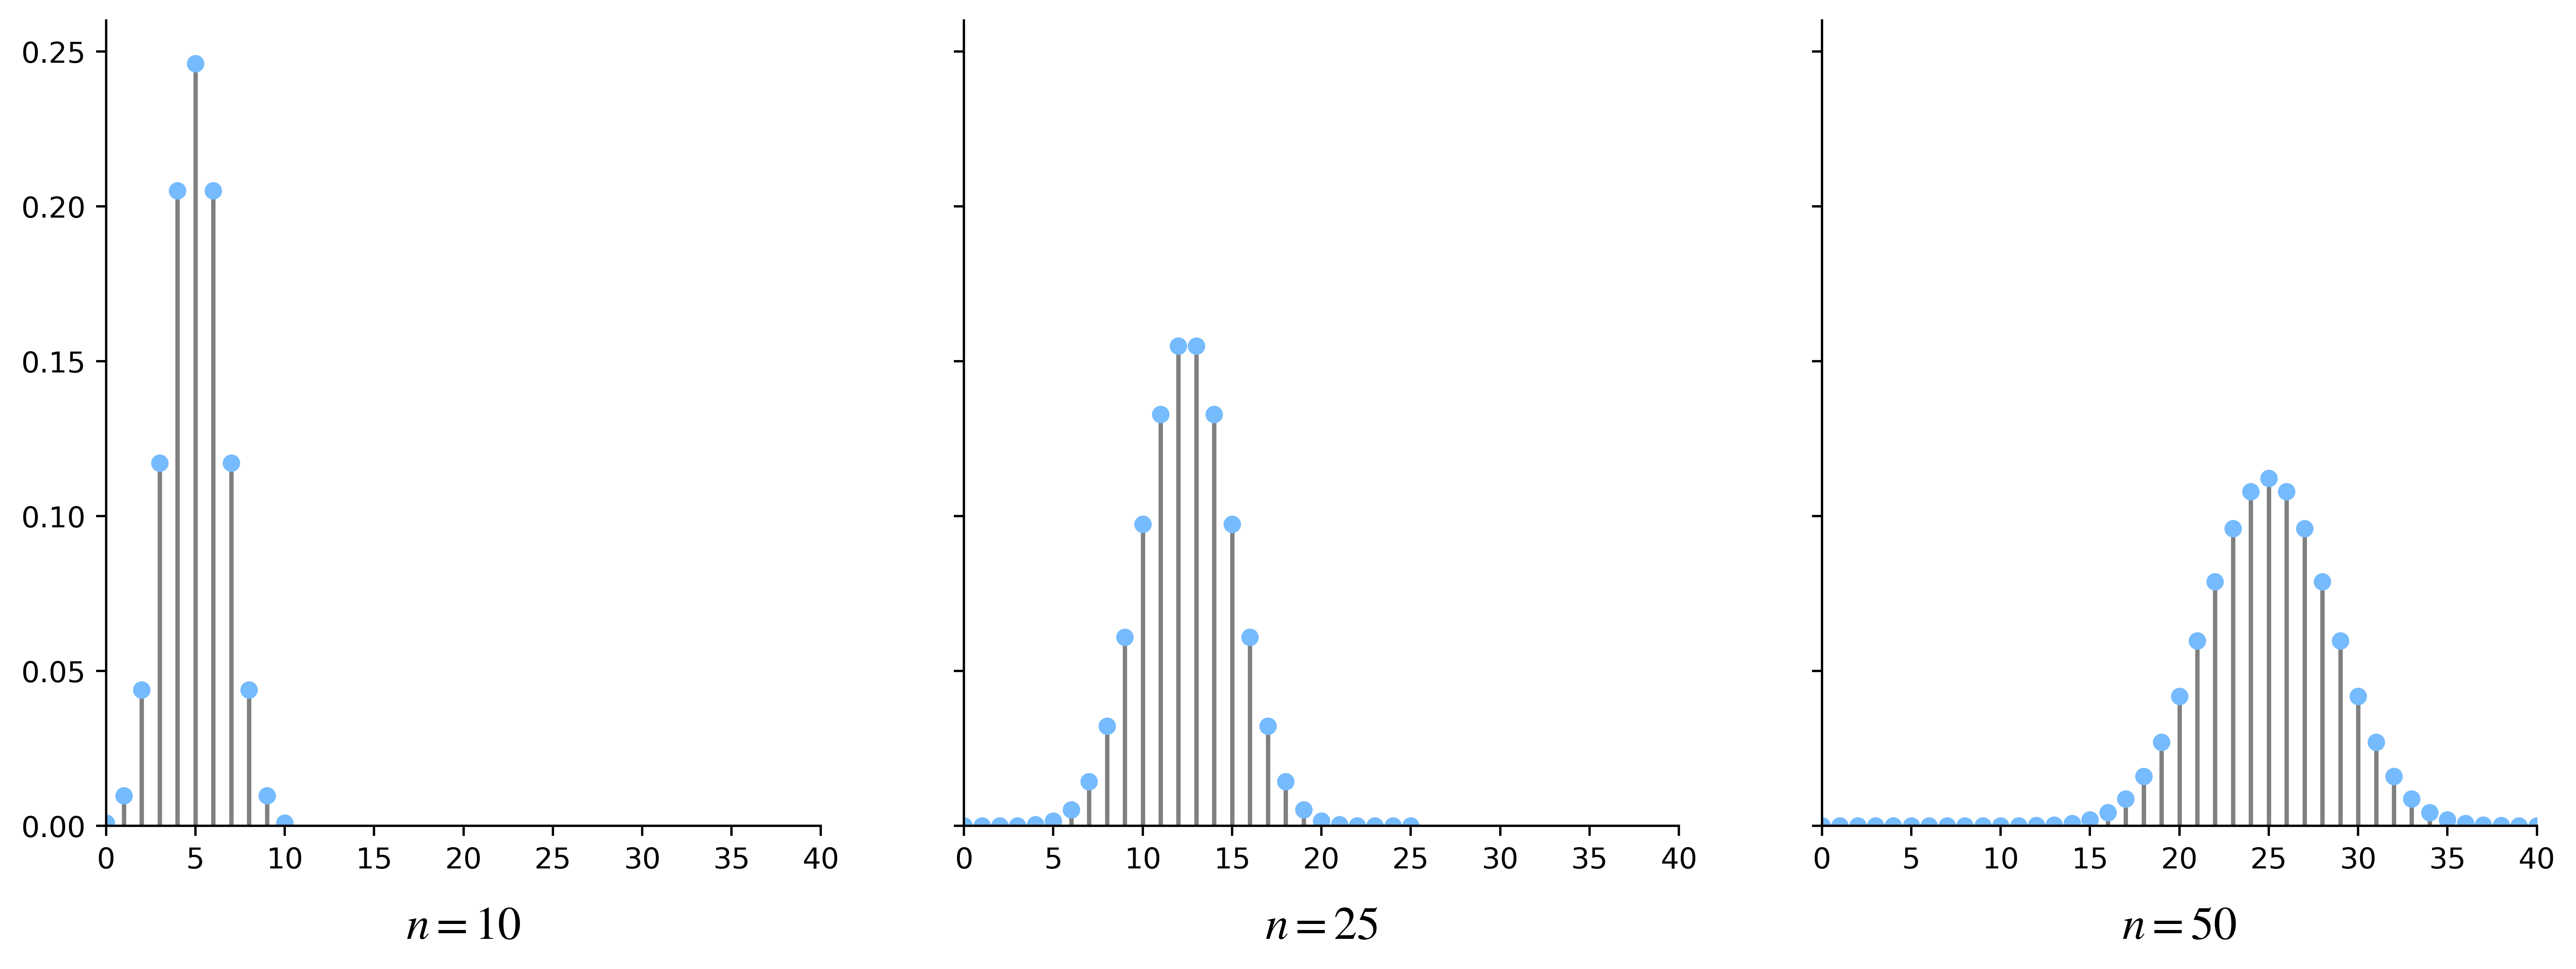

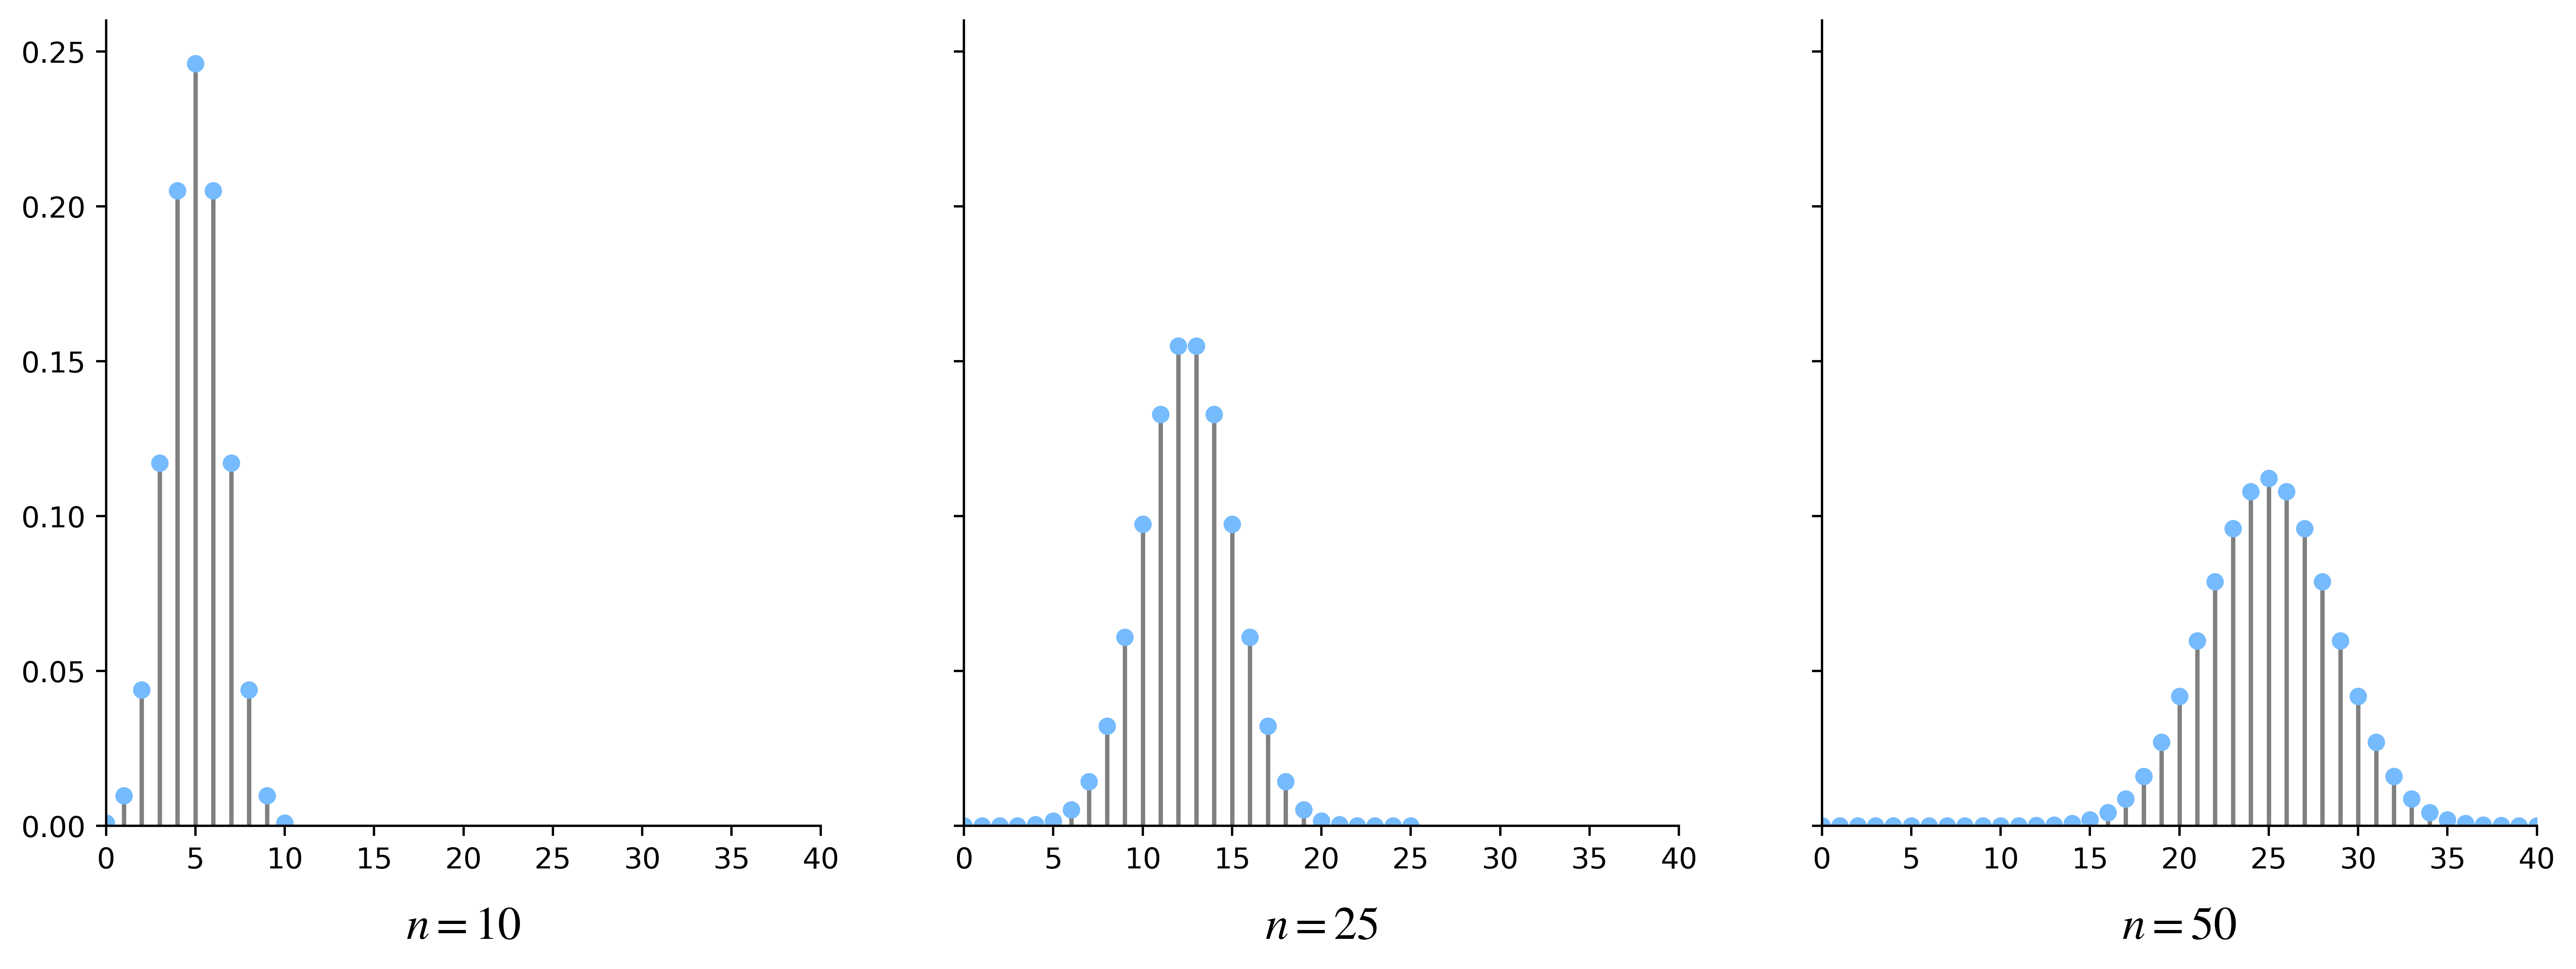

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
from myst_nb import glue

#plt.style.use('sds.mplstyle')

p = 0.5
ns = [10, 25, 50]

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15, 5))

for n, ax in zip(ns, axes):
    x = np.arange(0, n+1)
    B  = st.binom(n, p)
    y = B.pmf(x)
    ax.vlines(x, 0, y, color='gray')
    ax.plot(x, y, 'o', ms=5)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, 0.26)

    ax.set_xlabel(rf'$n={n}$')
plt.show()

glue("binomial-divergence", fig, display=True)

```{glue:figure} binomial-divergence
:name: fig:binomial-divergence

Grafici della funzione di massa di probabilità di $X_n$ per $n = 10, 25
\text{ e } 50$.
```

Possiamo però considerare una trasformazione di $X_n$ che renda la
distribuzione del risultato indipendente da $n$ relativamente alla sua
centralità e alla sua dispersione. Definiamo quindi $Y_n$ come la versione
standardizzata di $X_n$:

```{math}
Y_n \coloneqq \frac{X_n - n p}{\sqrt{n p (1 - p)}} \enspace.
```

Per le proprietà della trasformazione applicata, indipendentemente dal valore
di $n$ avremo che $Y_n$ ha valore atteso nullo e varianza unitaria, come
illustrato nella {numref}`Figura %s <fig:binomial-convergence>`. Questa
figura mette in evidenza anche il fatto che, al crescere di $n$, da una parte
le specificazioni di $Y_n$ tendono ad avvicinarsi l'un l'altra, e dall'altra
il _range_ di questa variabile aleatoria è un intervallo centrato nell'origine
che diventa sempre più grande, comprendendo sia numeri positivi, sia numeri
negativi. Diventa quindi ragionevole valutare l'ipotesi che, in analogia a
quanto visto nel {numref}`Paragrafo %s <sec:modello-esponenziale>`, la
distribuzione di $Y_n$ tenda a una distribuzione di tipo continuo che ha
$\mathbb R$ come supporto.

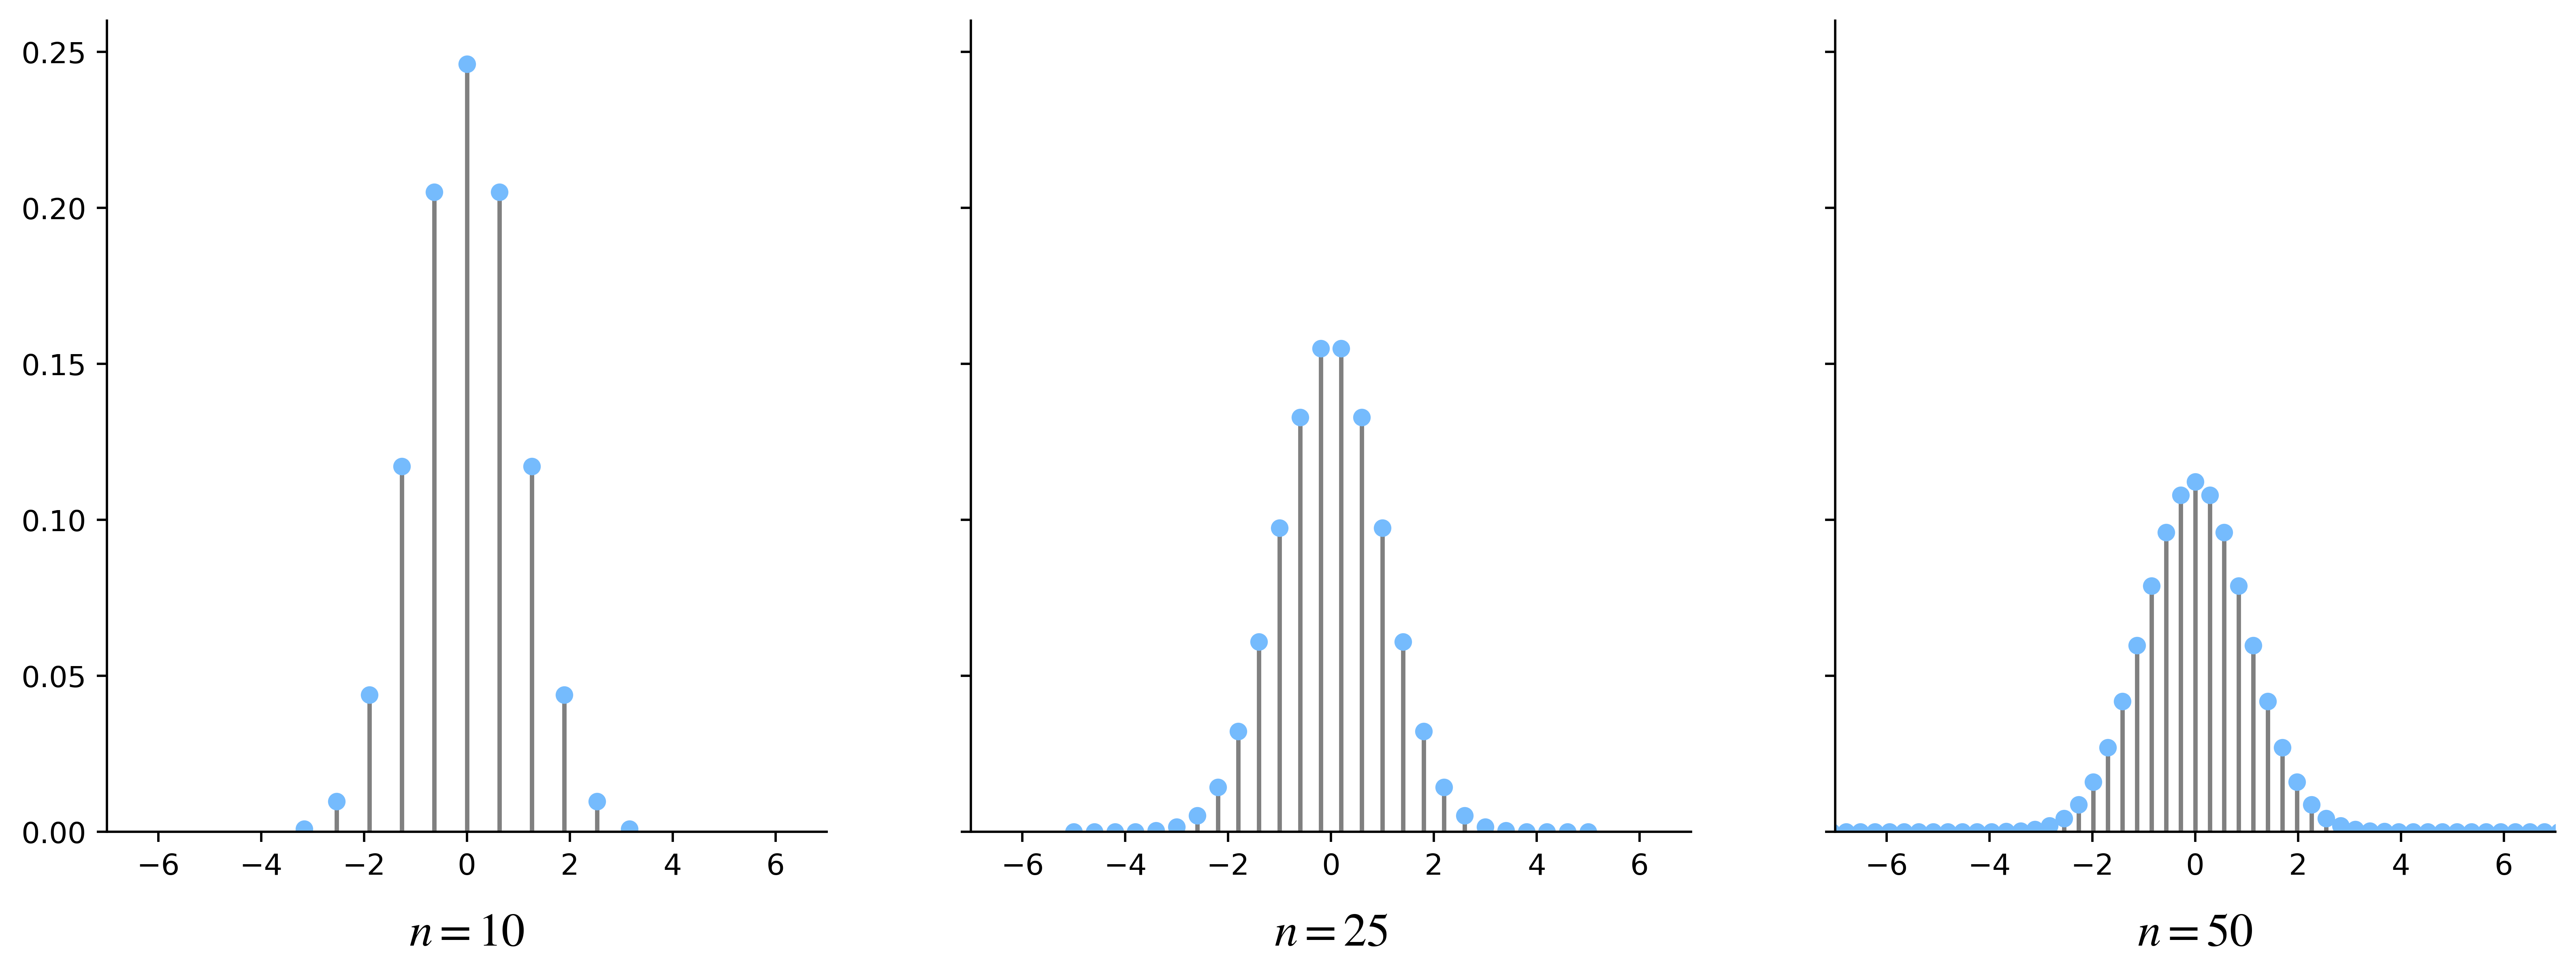

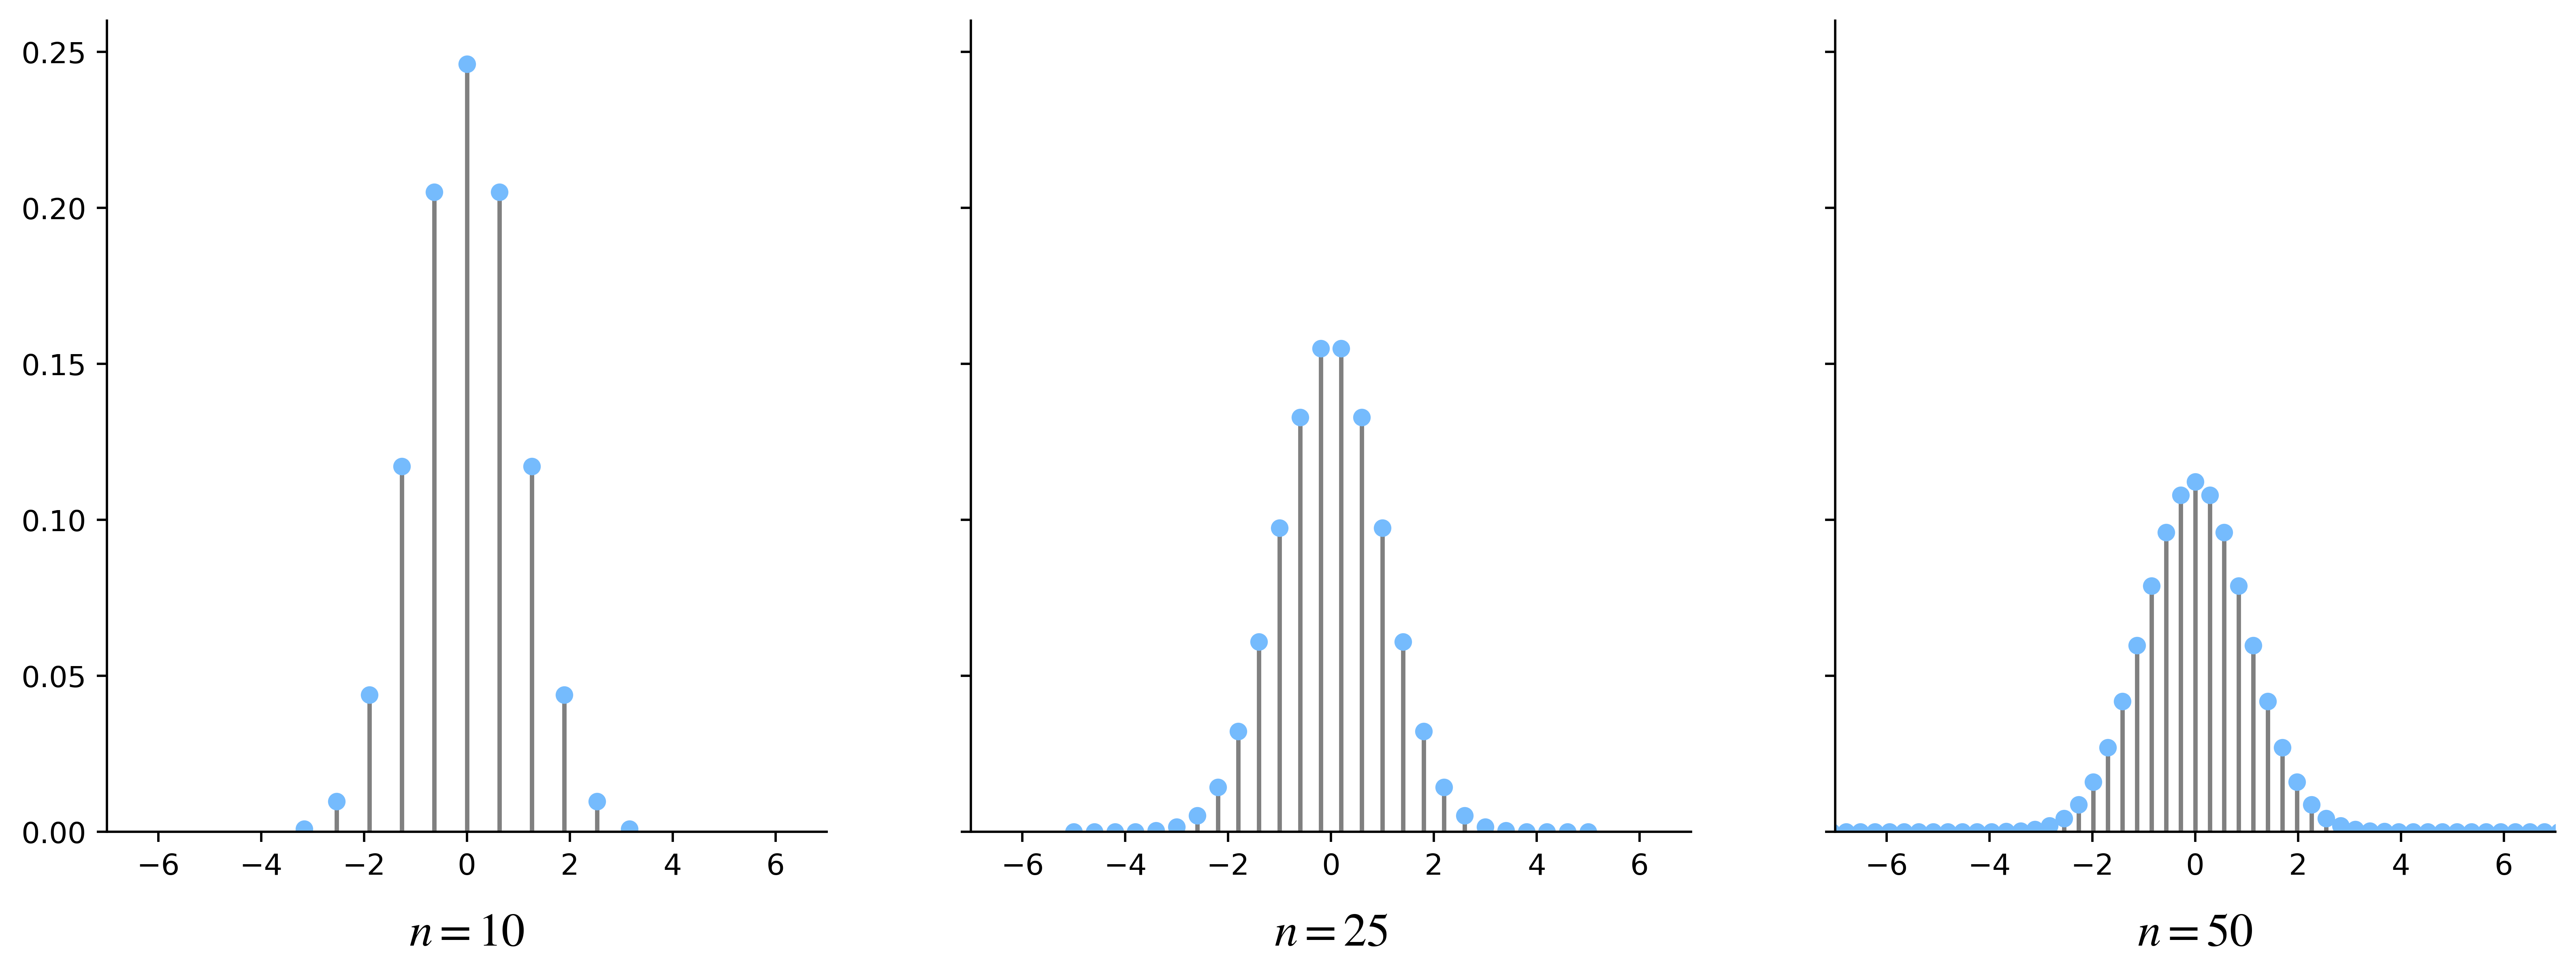

In [2]:
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15, 5))

for n, ax in zip(ns, axes):
    x = np.arange(0, n+1)
    x_norm = (x - n*p) / (n * p * (1-p))**0.5
    B  = st.binom(n, p)
    y = B.pmf(x)
    ax.vlines(x_norm, 0, y, color='gray')
    ax.plot(x_norm, y, 'o', ms=5)
    ax.set_xlim(-7, 7)
    ax.set_ylim(0, 0.26)

    ax.set_xlabel(rf'$n={n}$')
plt.show()

glue("binomial-convergence", fig, display=True)

```{glue:figure} binomial-convergence
:name: fig:binomial-convergence


Grafici della funzione di massa di probabilità di $Y_n$ per $n = 10, 25
\text{ e } 50$.
```

Possiamo verificare empiricamente come, in effetti, man mano che $n$ cresce
$Y_n$ tende a seguire una distribuzione continua descritta dalla funzione
di densità di probabilità

```{math}
:label: eq:normal-pdf
\phi(x) \coloneqq \frac{1}{\sqrt{2 \pi}} \mathrm e^{-\frac{x^2}{2}} \enspace,
```

il cui grafico è visualizzato nella {numref}`Figura %s <fig:normal-pdf>`.
Questa distribuzione, che definiremo rigorosamente più avanti, ha un ruolo
particolarmente importante e viene chiamata _distribuzione normale standard_.

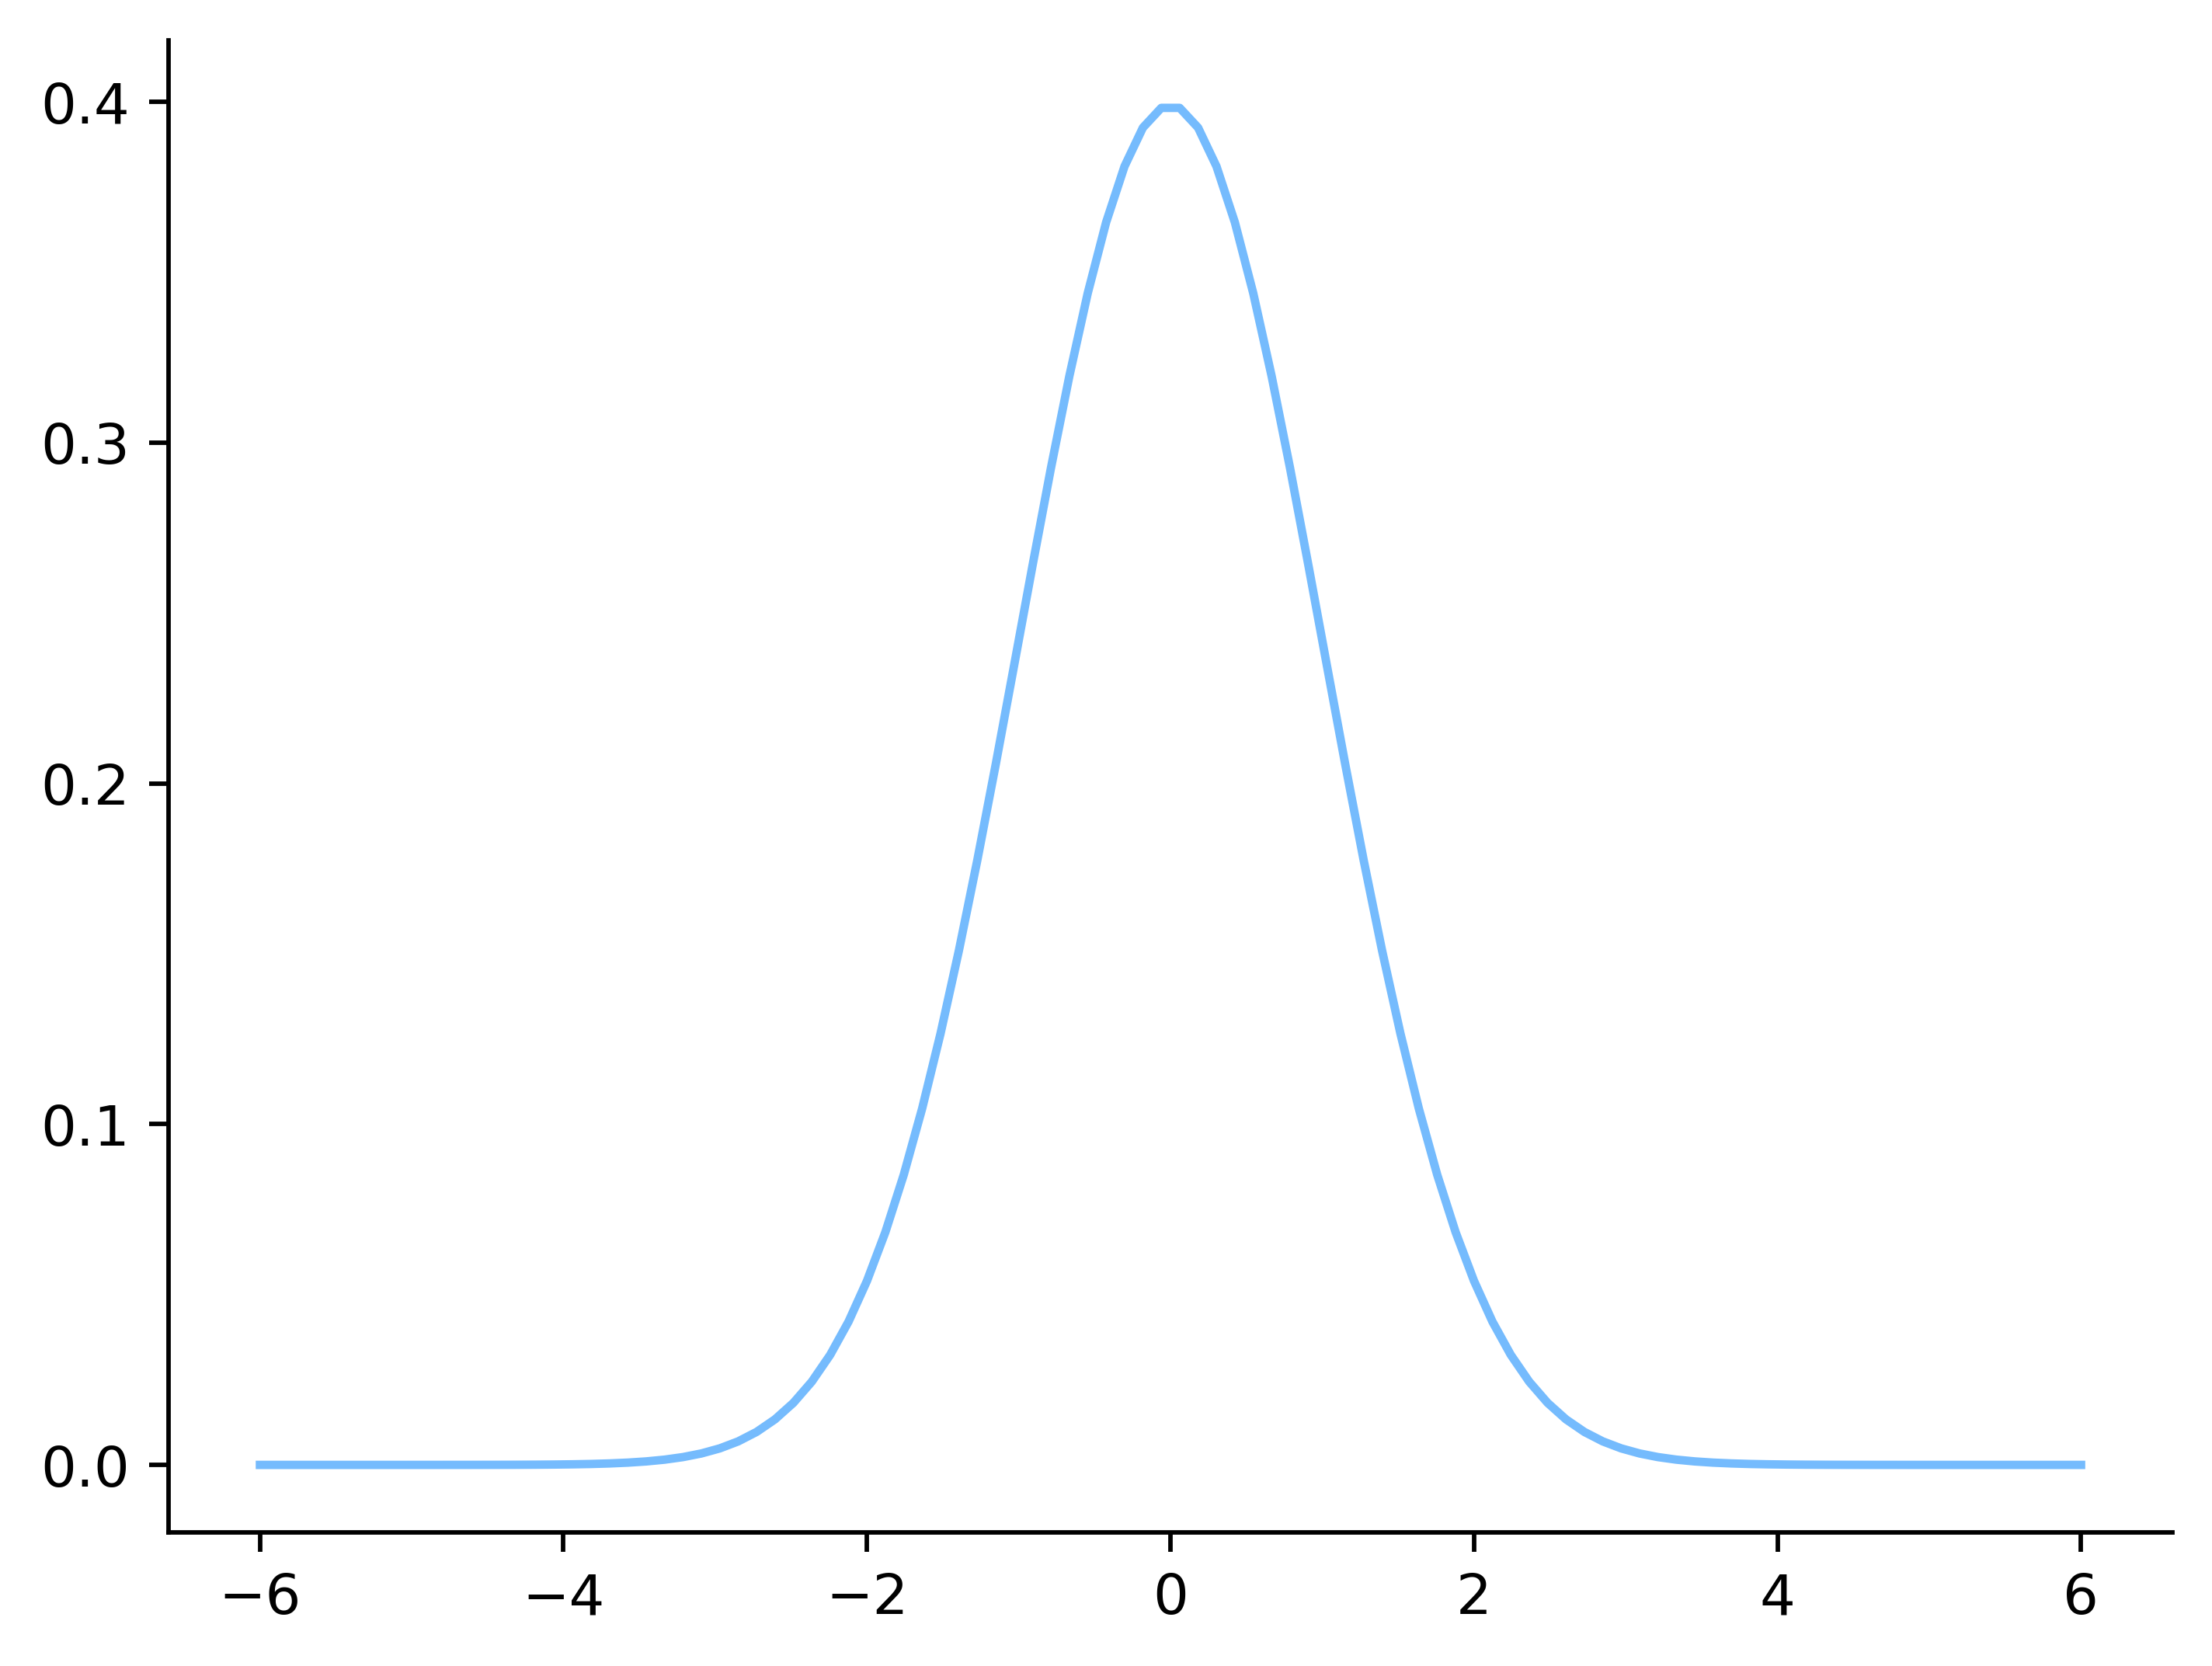

In [3]:
fig, ax = plt.subplots()

def std_normal_pdf(x):
    return 1 / (2 * np.pi)**0.5 * np.exp(- x**2 / 2)

x_gauss = np.linspace(-6, 6, 100)
y_gauss = std_normal_pdf(x_gauss)

plt.plot(x_gauss, y_gauss)
plt.yticks([0, 0.1, 0.2, 0.3, 0.4])

glue("normal-pdf", fig, display=False)

```{glue:figure} normal-pdf
:name: fig:normal-pdf
:figwidth: 400px


Grafico della funzione di densità della distribuzione normale
standard.
```

```{margin}
Il fatto che le altezze dei bastoncini in {numref}`fig:binomial-convergence`
sommino a $1$ spiega anche come mai queste stesse altezze tendano a diminuire
quando $n$ cresce.
```
Per verificare questo fatto è però necessario considerare un ulteriore
passaggio intermedio: per ogni $n$, $Y_n$ è una variabile aleatoria discreta,
mentre la distribuzione limite che stiamo considerando è continua. Nel
primo caso, la somma delle altezze dei bastoncini nella
{numref}`Figura %s <fig:binomial-convergence>` è uguale a $1$, mentre nel
secondo è la regione di piano delimitata dall'asse delle ascisse e dalla curva
mostrata in {numref}`Figura %s <fig:normal-pdf>` ad avere area unitaria.
Per poter confrontare correttamente le distribuzioni in gioco dobbiamo
pertanto o «trasformare» $Y_n$ in una variabile aleatoria continua, oppure
al contrario considerare un equivalente discreto della distribuzione normale
standard.

```{margin}
Avremmo potuto considerare il processo inverso, ottenendo gli stessi
risultati, ma ciò sarebbe stato più complicato e avrebbe richiesto
il ricorso al calcolo integrale.
```
Procediamo costruendo una distribuzione continua che preservi in qualche
senso le probabilità che definiscono $Y_n$. Più precisamente, per $n$ fissato
vogliamo definire una variabile aleatoria continua $Y'_n$ in modo tale da
«spalmare» la massa di probabilità di ogni specificazione $y \in D_{Y_n}$
in un suo opportuno intorno $I_y$, garantendo che
$\mathbb P(Y'_n \in I_y) = \mathbb P(Y_n = y)$. Ci sono vari modi per
effettuare questa operazione: uno di quelli più naturali consiste nel centrare
ogni $I_y$ nella relativa specificazione $y$, utilizzando un'ampiezza costante
scelta in modo da garantire che la famiglia di questi intervalli sia una
partizione del range di $Y_n$. In altre parole, indicate con
$y_1, \dots, y_{n+1}$ le specificazioni di $Y_n$, per ogni $i = 1, \dots, n+1$
possiamo convertire il bastoncino della
{numref}`Figura %s <fig:binomial-convergence>` posizionato nell'ascissa $y_i$
in una barra della medesima altezza la cui base è
$[(y_{i-1} + y_i)/2, (y_i + y_{i+1})/2)$ (con ovvie estensioni per i casi
estremi che riguardano $y_1$ e $y_{n+1}$). A questo punto è possibile
considerare la funzione che, dato $x \in \mathbb R$ compreso in uno degli
intervalli restituisce l'altezza della barra corrispondente, e il cui valore è
zero per i punti rimanenti. L'area della regione delimitata dal grafico di
questa funzione e dall'asse delle ascisse non è però uguale a $1$, ma è
possibile normalizzare la funzione stessa, dividendo ogni valore da essa
restituito per la somma delle aree delle barre. Il risultato è una funzione
$f_n$ che può essere interpretata come densità di probabilità e quindi
confrontata con $\phi$: la {numref}`Figura %s <fig:normal-convergence>`
mostra come effettivamente la prima funzione tenda a coincidere con la seconda
all'aumentare di $n$.

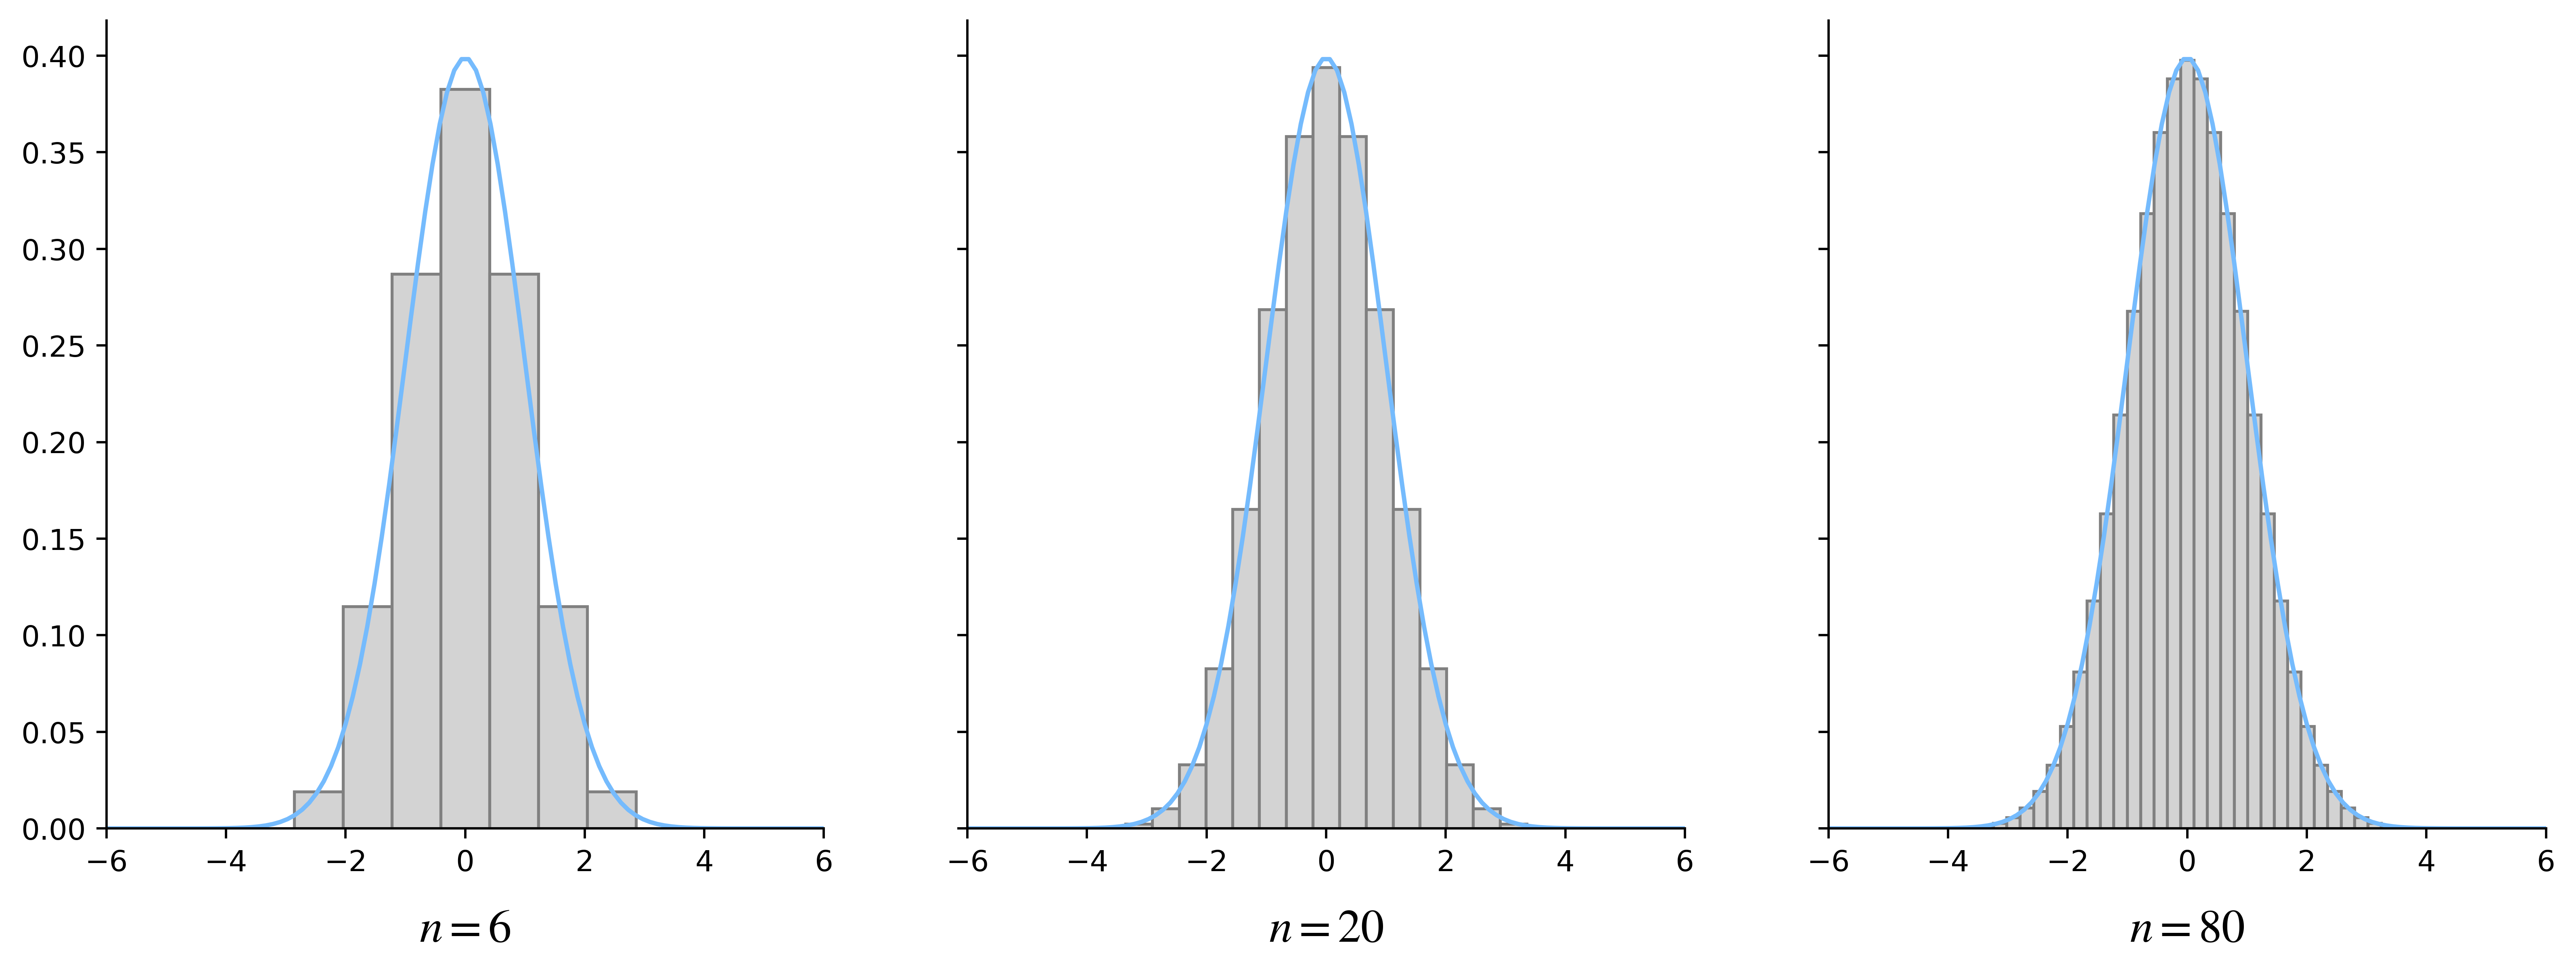

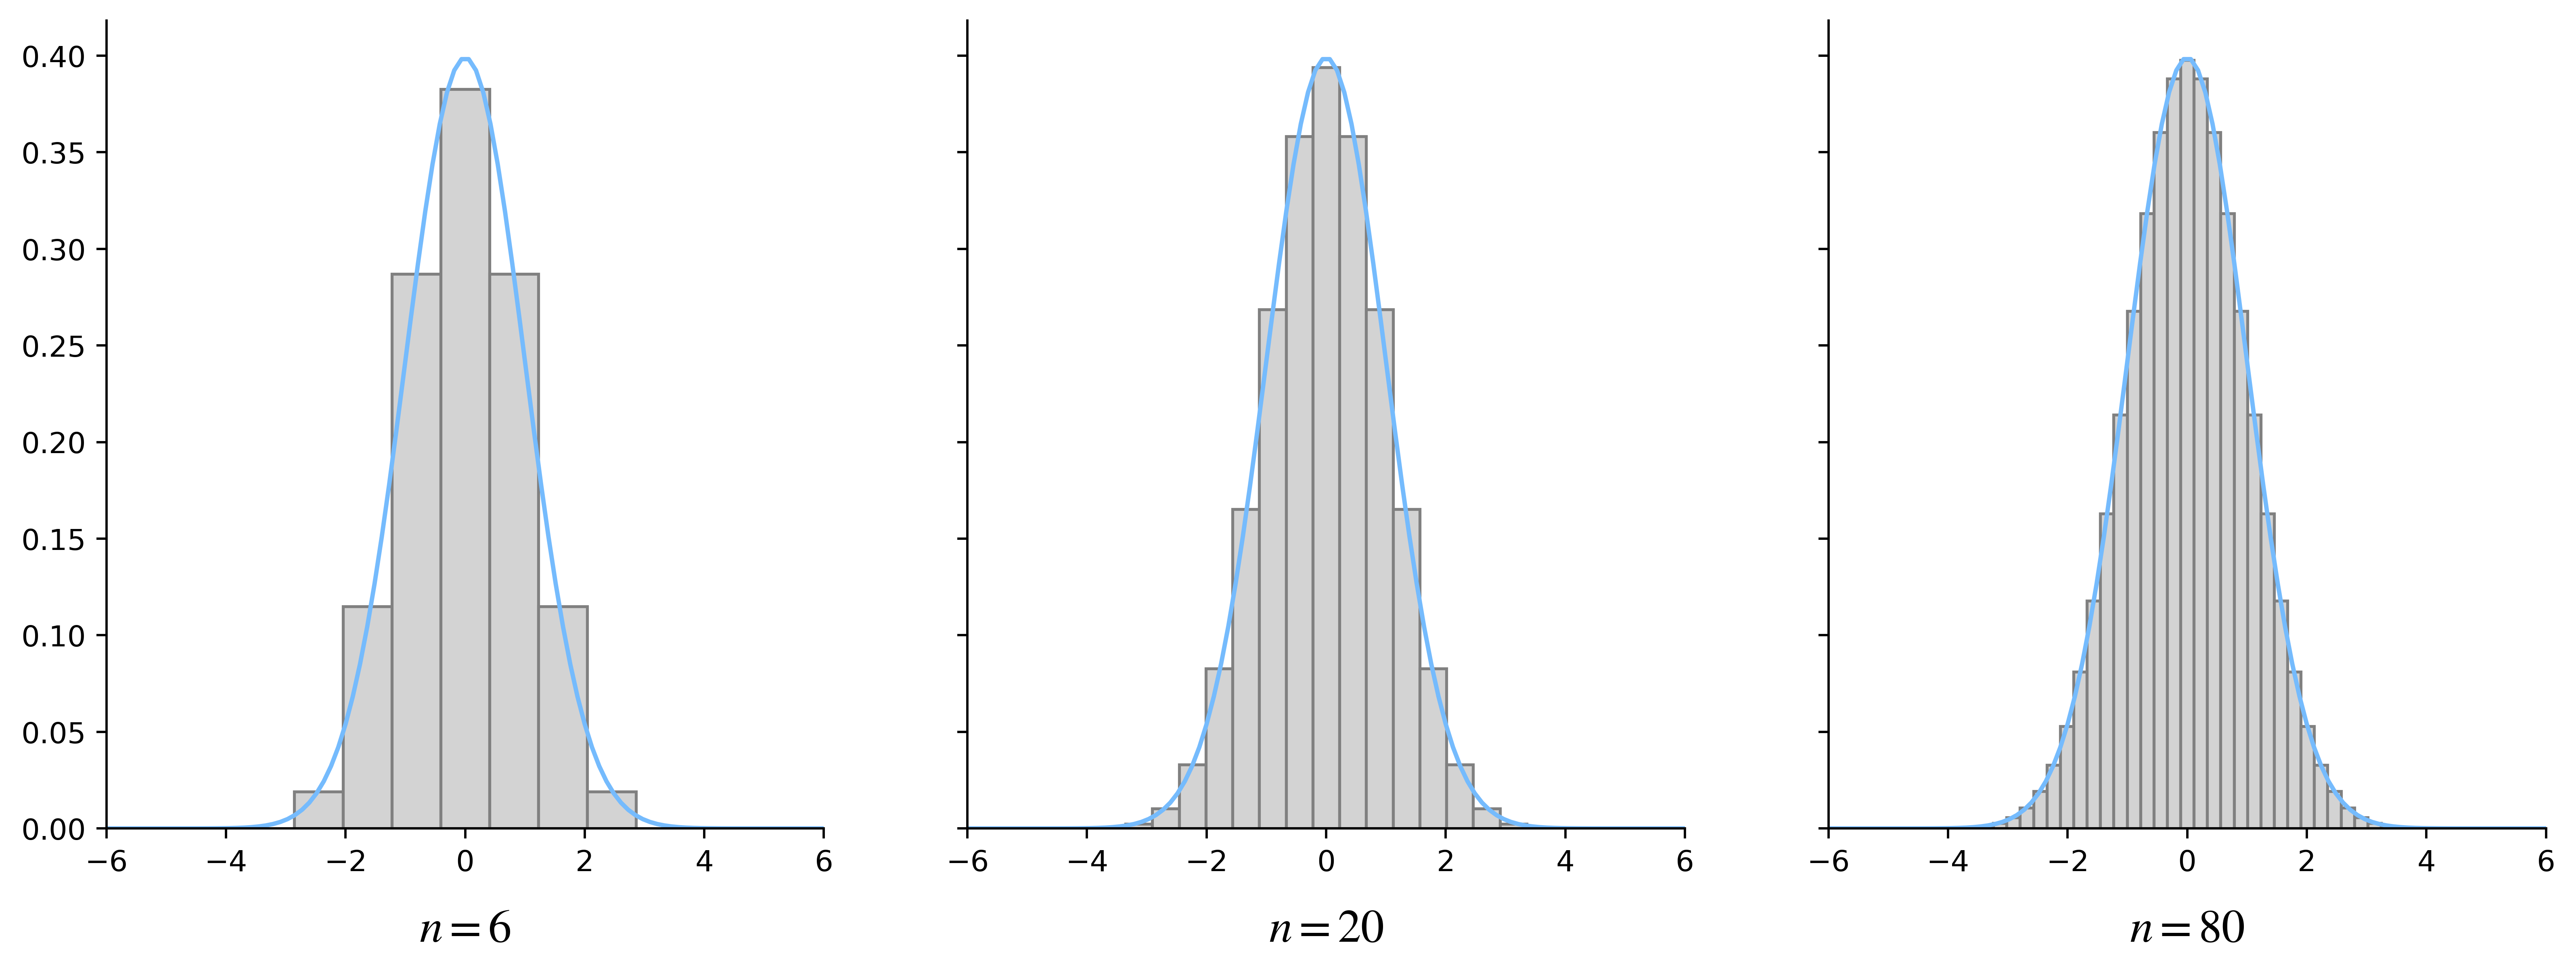

In [4]:
def binomial(n, p=0.5):
    B = st.binom(n, p)
    x = np.arange(0, n+1)
    x_norm = (x - n*p) / (n * p * (1-p))**0.5
    y = B.pmf(x)
    y_norm = y * (n * p * (1-p))**0.5
    return x_norm, y_norm

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15, 5))

for n, ax in zip([6, 20, 80], axes):
    x, y  = binomial(n, p)
    ax.bar(x, y, color='lightgray', edgecolor='gray',
           width=1 / (n * p * (1-p))**0.5)
    ax.plot(x_gauss, y_gauss)
    ax.set_xlim(-6, 6)

    ax.set_xlabel(rf'$n={n}$')
plt.show()

glue("normal-convergence", fig, display=True)

```{glue:figure} normal-convergence
:name: fig:normal-convergence

Convergenza di $f_n$ alla densità $\phi$ della distribuzione normale standard.
I grafici a barre visualizzano l'area delimitata da $f_n$, per
$n = 10, 100 \text{ e } 250$, mentre la curva blu indica il grafico di $\phi$.
```

Il ragionamento informale seguito finora può essere rivisto in modo formale,
in particolare considerando il teorema di de Moivre-Laplace.

````{prf:theorem} Teorema di de Moivre-Laplace
:label: teo:demoivre-laplace

Dati $n \in \mathbb N$ e $p \in [0, 1]$, sia $X \sim \mathrm B(n, p)$.
Definita $Y_n \coloneqq (X_n - np) / \sqrt{n p (1-p)}$, quando $n \to +\infty$
la distribuzione di $Y_n$ tende a quella normale standard.
````

La dimostrazione del teorema di de Moivre-Laplace, relativamente complessa,
è riportata nel {numref}`Paragrafo opzionale %s <sec:teo-de-moivre-laplace>`.
In ogni caso, per quanto visto finora ha senso ragionare in termini di una
variabile aleatoria $X$ che abbia $\phi$ come densità di probabilità, e più in
generale parlare della distribuzione continua normale standard. Vi sono alcune
proprietà di questa distribuzione che possiamo ricavare, sempre in modo
informale. Innanzitutto {eq}`eq:normal-pdf` descrive effettivamente una
densità di probabilità in quanto $\phi$ è una funzione non negativa il cui
integrale su $\mathbb R$ è uguale a $1$: dimostrarlo in modo formale richiede
qualche conoscenza di analisi matematica avanzata (in particolare, la capacità
di calcolare integrali doppi), ma possiamo convincerci facilmente che sia
così, avendo verificato sperimentalmente che $\phi$ è il limite di $f_n$, e
per ogni $n$ quest'ultima funzione è stata costruita in modo che l'area tra il
suo grafico e l'asse delle ascisse valga esattamente $1$. Risulta inoltre
facile calcolare il valore atteso di $X$: se definiamo
$g(x) \coloneqq x \phi(x)$, per ogni $x$ vale $g(-x) = -g(x)$, essendo $\phi$
una funzione pari (cioè una funzione simmetrica rispetto all'asse delle
ordinate). Dunque

```{math}
\mathbb E(X) = \int_{-\infty}^{+\infty}g(x) \; \mathrm d x = 0 \enspace.
```

```{margin}
Ottenere $\mathrm{Var}(X)$ applicando la relativa definizione richiede
conoscenze relativamente avanzate di analisi matematica: precisamente,
è necessario risolvere un integrale non banale in termini di una particolare
funzione detta _funzione gamma_.
```
D'altra parte, la distribuzione di $X$ è il limite di una serie di
distribuzioni che sono tutte centrate in $0$, in quanto le variabili aleatorie
$Y_n$ sono state ottenute standardizzando le corrispondenti $X_n$. Seguendo un
ragionamento analogo, è facile convincersi che la varianza e la deviazione
standard di $X$ sono uguali a $1$. Da qui in avanti supporremo quindi che
che $\mathbb E(X) = 0$ e $\mathrm{Var}(X) = 1$ (cosa che è effettivamente
vera, e della quale i lettori interessati troveranno una dimostrazione nel
{numref}`Paragrafo opzionale %s <sec:norm-fgm>`). Le cose diventano più
complicate quando si considera la funzione di ripartizione di $X$, che viene
indicata con il simbolo $\Phi$. Ovviamente vale

```{math}
\Phi(x) = \mathbb P(X \leq x) = \int_{-\infty}^x \phi(u) \; \mathrm d u
          \enspace,
```

ma non è possibile esprimere analiticamente questo integrale in termini di
funzioni che già conosciamo [^calcolo-cdf-normale]. Per questo motivo $\Phi$
viene calcolata ricorrendo a processi di approssimazione numerica
[^approssimazione-integrali]. Vedremo nel 
{numref}`Paragrafo %s <sec:implementazione-modello-normale>` che questo
processo è fatto in modo trasparente dal modulo Python `scipy.stats`, che vale
la pena utilizzare nelle applicazioni pratiche. Ma possiamo per il momento
ottenere i valori di $\Phi$ ricavando direttamente l'approssimazione degli
integrali coinvolti. In particolare, la funzione `quad` presente nel modulo
`scipy.integrate` permette di calcolare questa approssimazione, specificando
come argomenti la funzione integranda e gli estremi di integrazione. Per
esempio, nella cella che segue calcoliamo $\Phi(0)$.

```{margin}
La costante `inf` definita in Numpy permette di specificare degli estremi di
integrazione infiniti. Va notato inoltre come per brevità la funzione
integranda sia stata specificata utilizzando una funzione anonima.
```

In [5]:
from scipy.integrate import quad

quad(lambda x: 1/(2*np.pi)**0.5 * np.exp(-x**2 / 2), -np.inf, 0)

(0.4999999999999999, 5.089095697715545e-09)

La funzione `quad` restituisce una coppia che contiene, rispettivamente,
l'approssimazione cercata e una stima dell'errore effettuato
nell'approssimazione stessa. Effettivamente è facile convincersi che il
risultato è corretto, in quanto essendo $\phi$ simmetrica rispetto all'asse
delle ordinate e valendo il suo integrale su $\mathbb R$ esattamente $1$, deve
necessariamente essere $\Phi(0) = \frac{1}{2}$. Possiamo quindi definire una
funzione `cdf_normal` che approssima i valori di $\Phi$ e utilizzarla per
mostrare il suo grafico, sovrapponendolo a quello di $\phi$ per ottenere il
risultato mostrato nella {numref}`Figura %s <fig:normal-cdf>`.

```{margin}
In analogia con il codice precedentemente scritto, vogliamo che `cdf_normal`
sia una funzione _vettoriale_, cioè venga automaticamente applicata elemento
per elemento ai vettori che le vengono passati come argomenti, ma ciò è
incompatibile con `quad`. In casi come questo, si utilizza la funzione Numpy
`vectorize` che trasforma una funzione non vettoriale nel suo equivalente
vettoriale. 

```

In [6]:
def std_normal_cdf_scalar(x):
    return quad(lambda u: 1/(2*np.pi)**0.5 * np.exp(-u**2 / 2), -np.inf, x)[0]

std_normal_cdf = np.vectorize(std_normal_cdf_scalar)

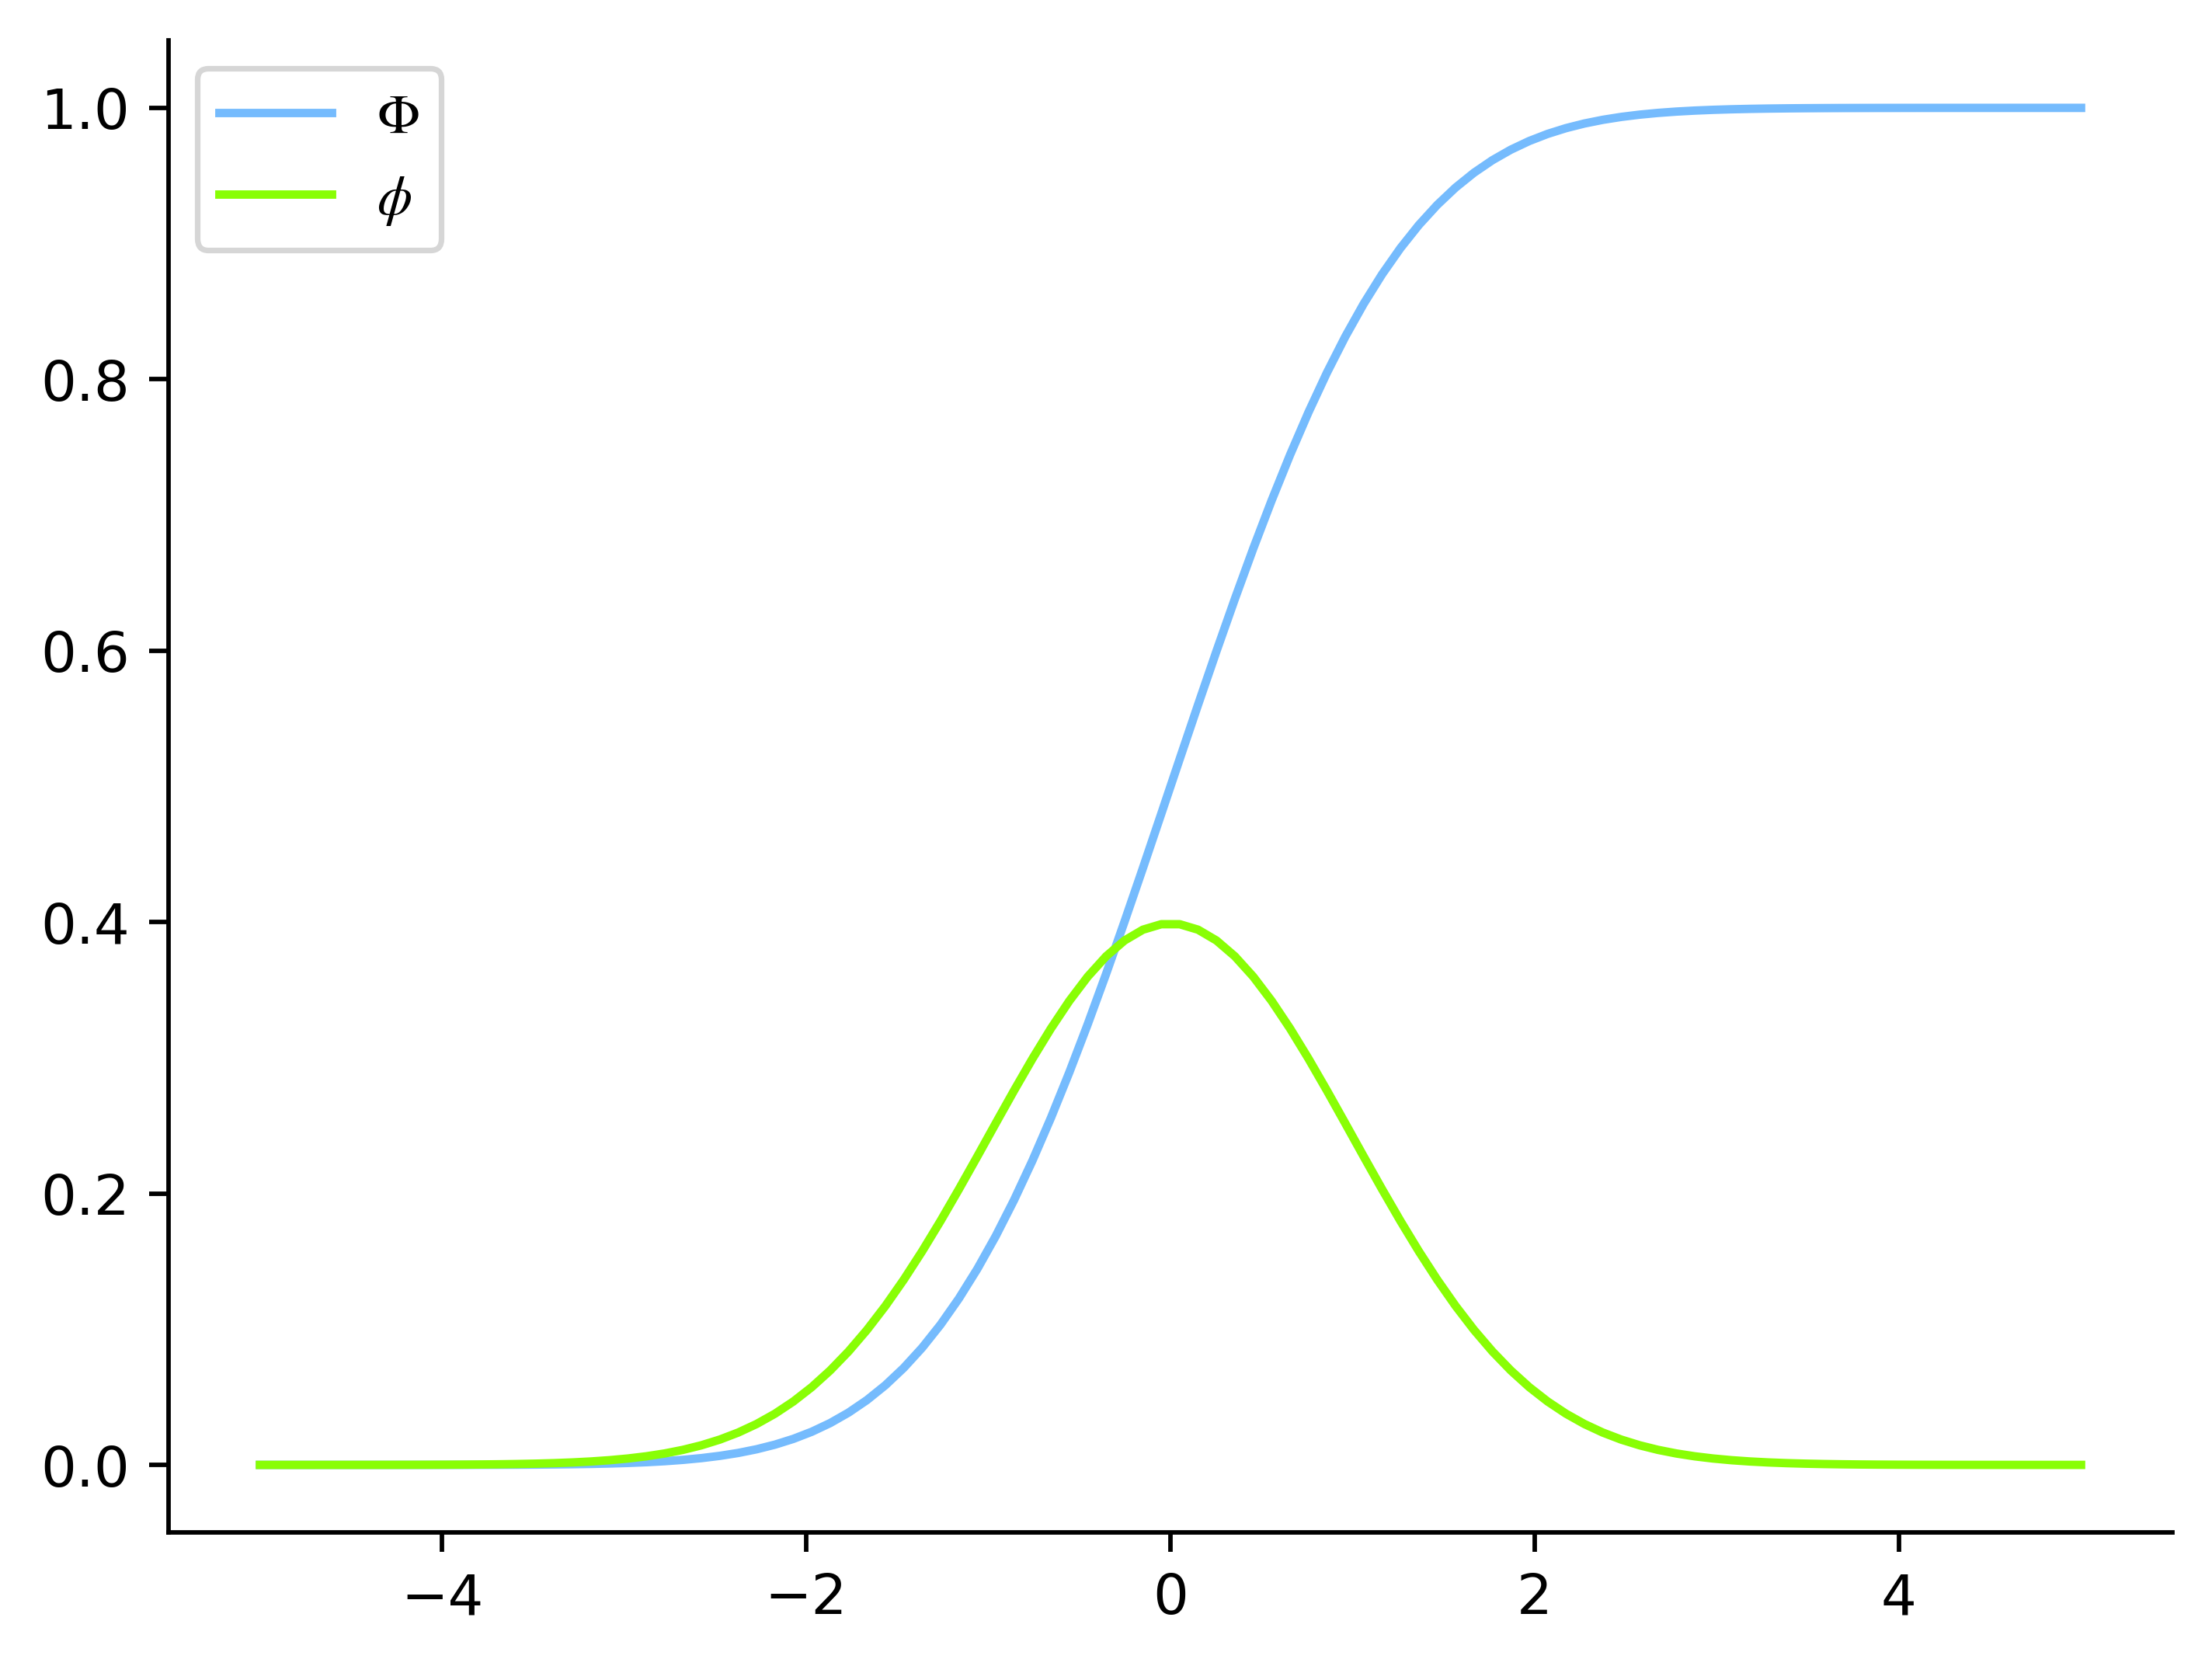

In [7]:
x = np.linspace(-5, 5, 100)
y_cdf = std_normal_cdf(x)
y_pdf = std_normal_pdf(x)

fig, ax = plt.subplots()
plt.plot(x, y_cdf, label=r'$\Phi$')
plt.plot(x, y_pdf, label=r'$\phi$')

plt.legend()
glue("normal-cdf", fig, display=False)

```{glue:figure} normal-cdf
:name: fig:normal-cdf
:figwidth: 400px

Grafico della funzione di ripartizione della distribuzione normale
standard (in blu) sovrapposto al grafico della corrispondente funzione
di densità di probabilità (in verde).
```

Nelle appendici di molti libri di testo di probabilità e statistica,
soprattutto in quelli più datati, è inclusa una tabella che contiene le
approssimazioni di $\Phi$ per dei particolari valori del suo argomento.
Ciò era fondamentalmente necessario quando non erano diffusi computer e
librerie come `scipy`, perché altrimenti non sarebbe stato possibile svolgere
esercizi, risolvere temi d'esame e soprattutto affrontare problemi pratici che
coinvolgono la distribuzione normale standard. Chiaramente, questo tipo di
tabella diventa inutile nel momento in cui possiamo scrivere ed eseguire
codice che ci permette di ottenere facilmente approssimazioni affidabili di
qualunque valore di $\Phi$. Ci sono però situazioni nelle quali anche oggi
questa tabella può tornare utile, per esempio nel caso in cui non sia
possibile accedere a un computer durante un esame scritto. La cella seguente
mostra come generare una tabulazione di valori approssimati per $\Phi$.

In [8]:
import pandas as pd

rows = []

most_significant = np.arange(0, 1.6, 0.1)
least_significant = np.arange(0, 0.1, 0.01)

for x_start in most_significant:
    row = []
    for x_end in least_significant:
        row.append(x_start+x_end)
    rows.append(std_normal_cdf(row))

df = (pd.DataFrame(rows, columns=least_significant, index=most_significant)
     .round(4))

df

,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
0.0,0.5000,0.5040,0.5080,0.5120,0.5160,0.5199,0.5239,0.5279,0.5319,0.5359
0.1,0.5398,0.5438,0.5478,0.5517,0.5557,0.5596,0.5636,0.5675,0.5714,0.5753
0.2,0.5793,0.5832,0.5871,0.5910,0.5948,0.5987,0.6026,0.6064,0.6103,0.6141
0.3,0.6179,0.6217,0.6255,0.6293,0.6331,0.6368,0.6406,0.6443,0.6480,0.6517
0.4,0.6554,0.6591,0.6628,0.6664,0.6700,0.6736,0.6772,0.6808,0.6844,0.6879
0.5,0.6915,0.6950,0.6985,0.7019,0.7054,0.7088,0.7123,0.7157,0.7190,0.7224
0.6,0.7257,0.7291,0.7324,0.7357,0.7389,0.7422,0.7454,0.7486,0.7517,0.7549
0.7,0.7580,0.7611,0.7642,0.7673,0.7704,0.7734,0.7764,0.7794,0.7823,0.7852
0.8,0.7881,0.7910,0.7939,0.7967,0.7995,0.8023,0.8051,0.8078,0.8106,0.8133
0.9,0.8159,0.8186,0.8212,0.8238,0.8264,0.8289,0.8315,0.8340,0.8365,0.8389


Il risultato ottenuto tabula i valori di $\Phi(x)$ per tutti i valori
$x$ che vanno da $0$ a $1.59$ a scatti di un centesimo. La tabella si legge
nel modo seguente: il valore contenuto nella cella che si trova nella
$i$-esima riga e nella $j$-esima colonna è un'approssimazione per $\Phi(i+j)$.
Per esempio, l'ultimo valore in basso a sinistra corrisponderà a $\Phi(1.5)$,
quello appena alla sua destra corrisponderà a $\Phi(1.51)$ e così via
[^interpolazione-lineare]. Nonostante la funzione di ripartizione della
distribuzione normale standard abbia valori non nulli anche per argomenti
negativi, la tabella è stata generata (esattamente come nei libri di testo
che di norma la contengono) considerando solo valori non negativi. Ciò viene
fatto per risparmiare spazio, in quanto i valori che corrispondono ad
argomenti negativi si possono facilmente ricavare da quelli tabulati,
sfruttando il seguente risultato.

````{prf:lemma}
Per ogni $x \in \mathbb R$ si ha $\Phi(-x) = 1 - \Phi(x)$.

```{prf:proof}
Data una variabile aleatoria $X$ con distribuzione normale
standard, sia $x \in \mathbb R^+$. Dalla simmetria di $\phi$ rispetto
all'asse delle ordinate, come evidenziato nella
{numref}`Figura %s <fig:normal-symmetry>`, si ottiene

\begin{align*}
\Phi(-x) &= \int_{-\infty}^{-x} \phi(x) \; \mathrm d x
          = \int_x^{+\infty} \phi(x) \; \mathrm d x \\
         &= \mathbb P(X > x)
          = 1 - \mathbb P(X \leq x)
          = 1 - \Phi(x) \enspace.
\end{align*}

L'estensione ai casi rimanenti è banale.
```
````

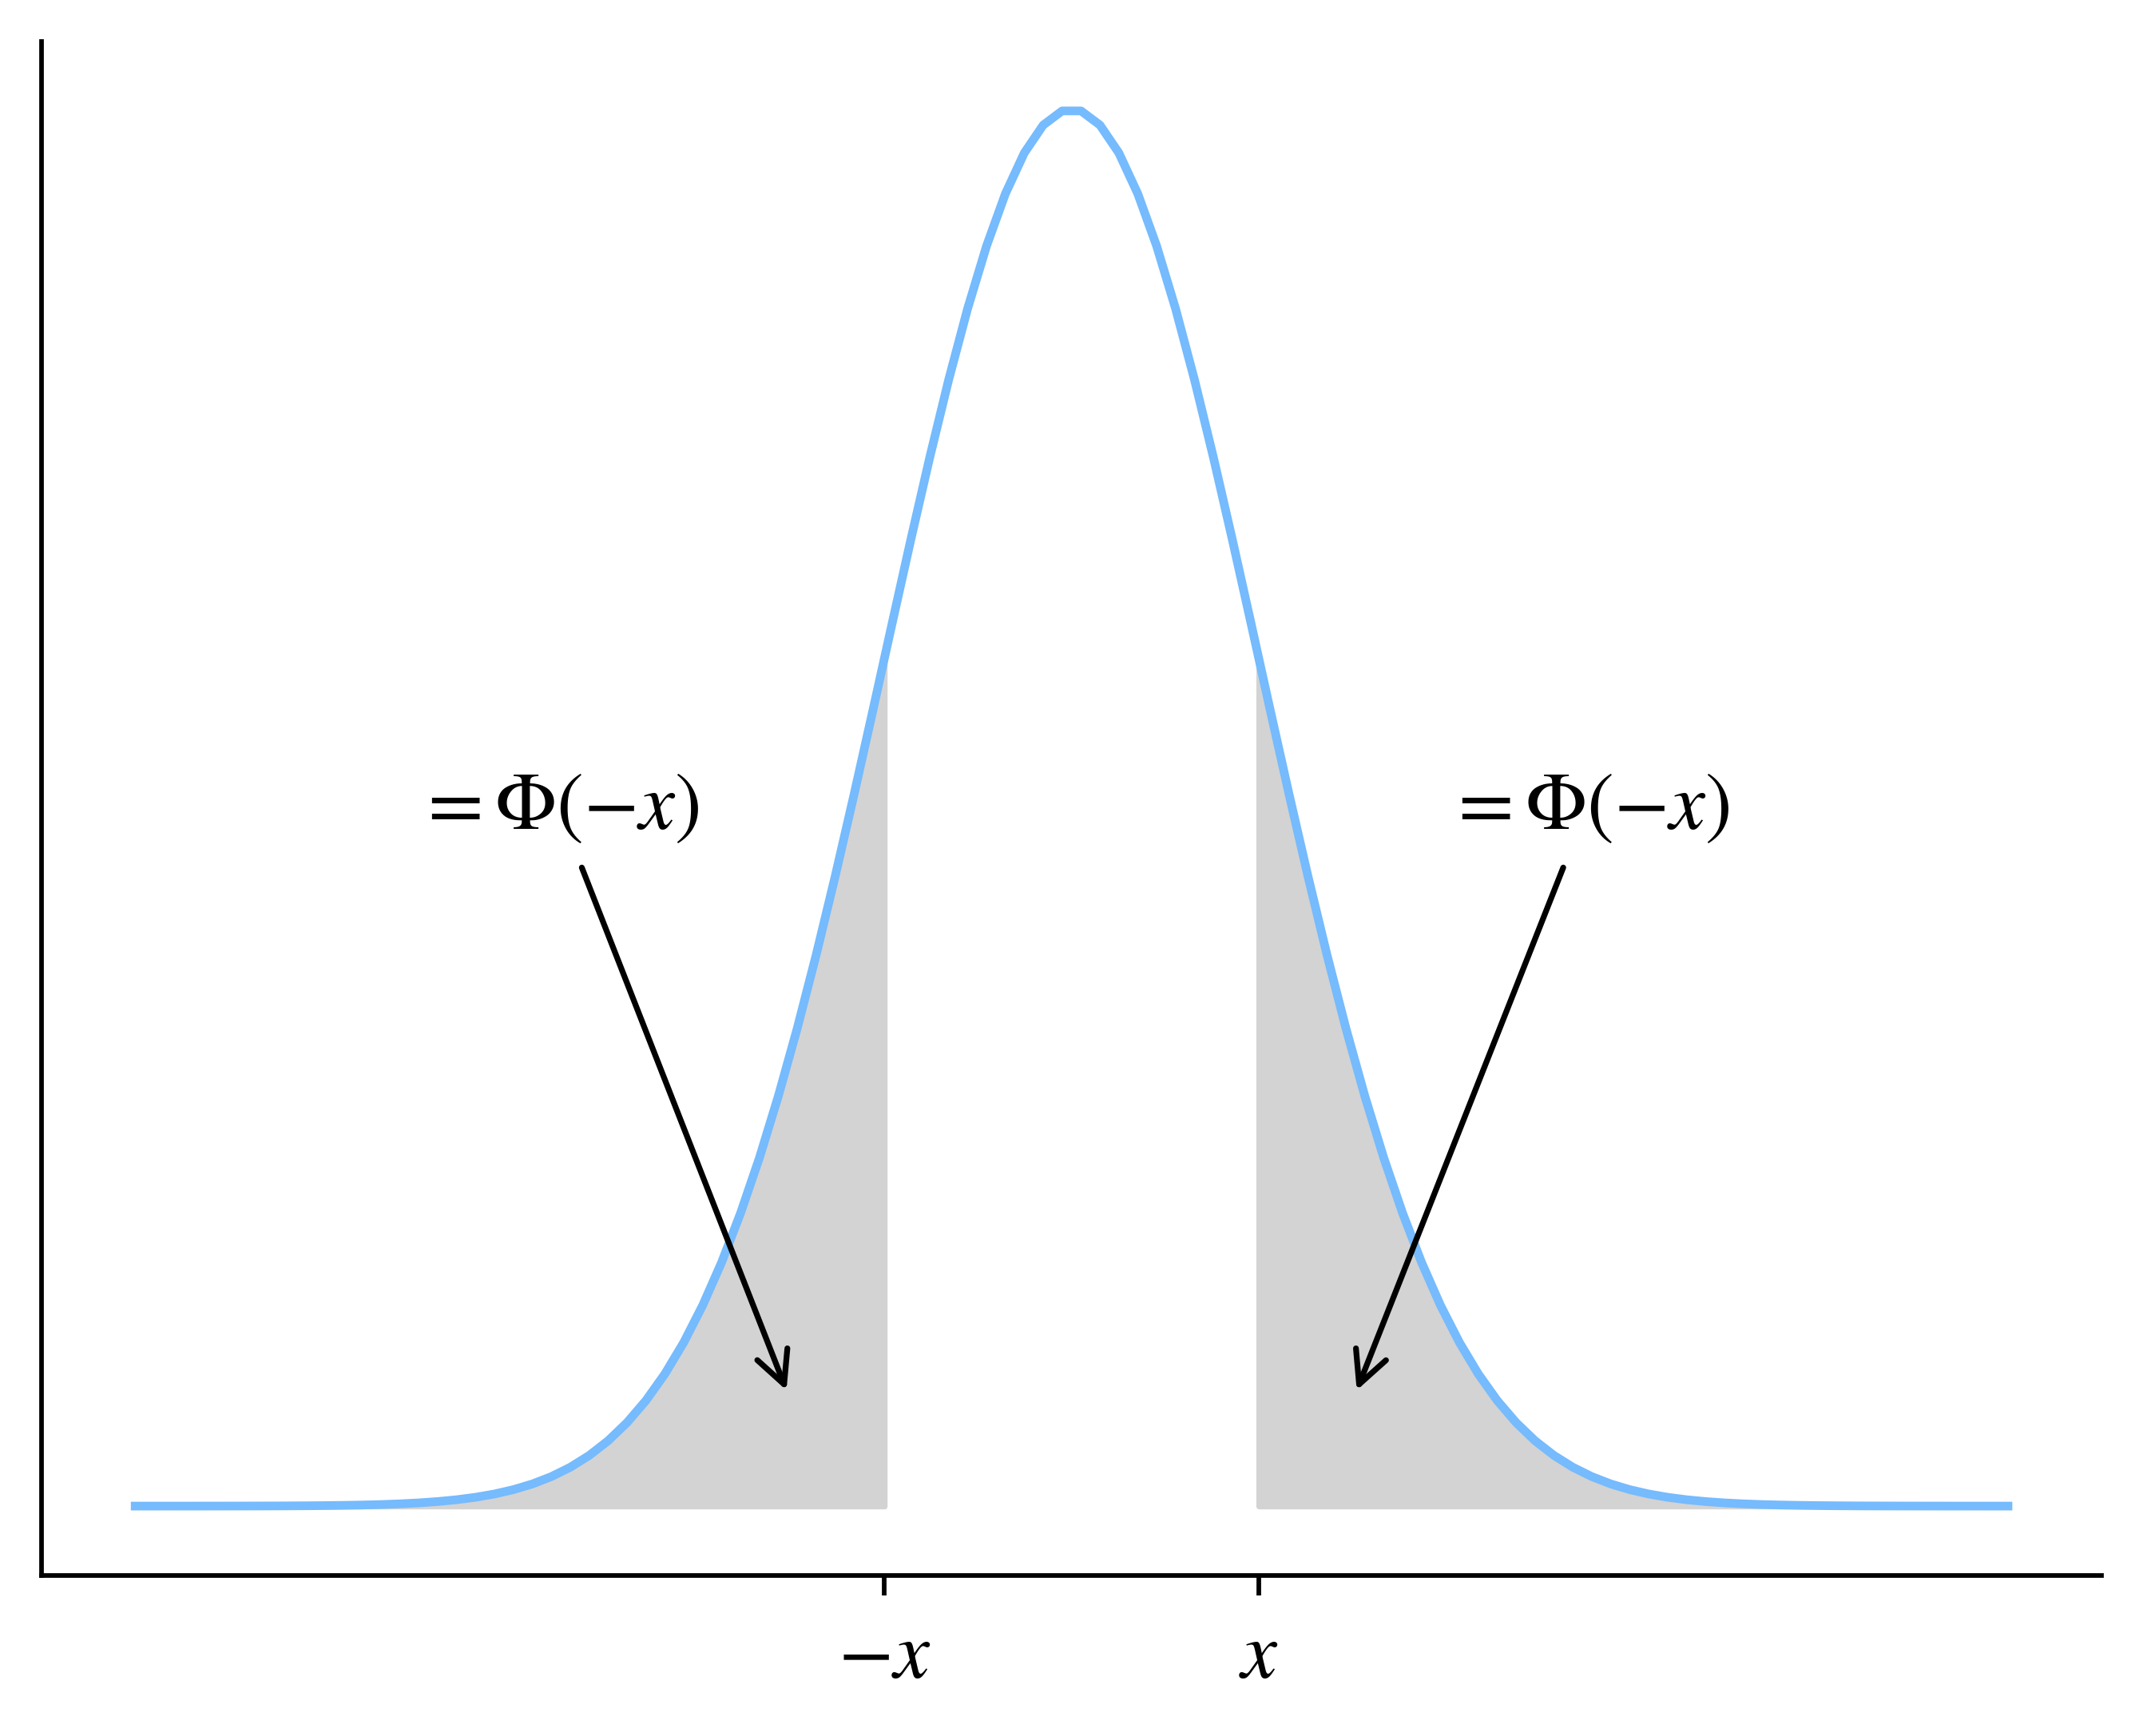

In [9]:
fig, ax = plt.subplots()

x_start = 1
x_fill = np.linspace(-5, -x_start, 50)
y_fill = std_normal_pdf(x_fill)
plt.fill_between(x_fill, 0, y_fill, color='lightgray')

x_fill = np.linspace(x_start, 5, 50)
y_fill = std_normal_pdf(x_fill)
plt.fill_between(x_fill, 0, y_fill, color='lightgray')

plt.plot(x, y_pdf)

plt.annotate(r'$=\Phi(-x)$', xy=(-1.5, 0.03), xytext=(-3.5, 0.2),
            arrowprops={'arrowstyle': '->', 'ec': 'black'},
            va='center', fontsize=14)

plt.annotate(r'$=\Phi(-x)$', xy=(1.5, 0.03), xytext=(2, 0.2),
            arrowprops={'arrowstyle': '->', 'ec':'black'},
            va='center', fontsize=14)

plt.xticks([-x_start, x_start], [r'$-x$', '$x$'], fontsize=14)
plt.yticks([])

glue("normal-symmetry", fig, display=False)

```{glue:figure} normal-symmetry
:name: fig:normal-symmetry
:figwidth: 400px

Relazione che lega la simmetria di $\phi$ rispetto all'asse delle ordinate
alla proprietà $\Phi(-x) = 1 -\Phi(x)$.
```

Fissiamo ora $\mu, \sigma \in \mathbb R$, con $\sigma > 0$, e definiamo
$Y \coloneqq \mu + \sigma X$. Sfruttando le proprietà di valore atteso e
varianza e ricordando quanto appena ricavato, si verifica facilmente che

\begin{align*}
\mathbb E(Y)    &= \mu + \sigma \mathbb E(X) = \mu \enspace, \\
\mathrm{Var}(Y) &= \sigma^2 \mathrm{Var}(X) = \sigma^2 \enspace.
\end{align*}

Inoltre

```{math}
:label: eq-normal-standardization

F_Y(x) = \mathbb P(Y \leq x) = \mathbb P(\mu + \sigma X \leq x)
       = \mathbb P\left(X \leq \frac{x - \mu}{\sigma} \right)
       = \Phi \left( \frac{x - \mu}{\sigma} \right)\enspace,
```

e quindi la funzione di densità di probabilità di $Y$ ha la seguente forma
analitica:

```{math}
f_Y(x) = F'_Y(x) = \phi \left( \frac{x - \mu}{\sigma} \right) \frac{1}{\sigma}
       = \frac{1}{\sqrt{2 \pi} \sigma}
                \mathrm e^{-\frac{(x - \mu)^2}{2 \sigma^2}} \enspace.
```

Pertanto, $\mu$ e $\sigma$ parametrizzano una distribuzione di probabilità
estendendo la distribuzione normale standard. Le distribuzioni in questa
famiglia vengono pertanto dette _normali_.

````{prf:definition} La famiglia delle distribuzioni normali

Dati $\mu \in \mathbb R$ e $\sigma \in \mathbb R^+$, la 
_distribuzione esponenziale_ di parametri $\mu$ e $\sigma$ è definita
dalla funzione di densità di probabilità

```{math}
f(x; \mu, \sigma) = \frac{1}{\sqrt{2\pi} \sigma}
                    \mathrm e^{-\frac{(x - \mu)^2}{2 \sigma^2}} \enspace,
```

o in modo equivalente dalla funzione di ripartizione

```{math}
F(x; \mu, \sigma) = \int_{-\infty}^x f(u; \mu, \sigma) \; \mathrm d x
                    \enspace.
```

Per indicare che una variabile aleatoria $X$ segue una distribuzione normale
utilizzeremo l'abbreviazione $X \sim \mathrm N(\mu, \sigma)$, dove $\mu$ e
$\sigma$ sono i valori per i parametri della distribuzione stessa.
L'insieme di tutte le distribuzioni normali al variare dei possibili
valori dei due relativi parametri viene detta _famiglia delle distribuzioni
normali_.
````

La distribuzione normale standard è una particolare distribuzione normale:
quella, ovviamente, per la quale $\mu = 0$ e $\sigma = 1$.
La {numref}`Figura %s <fig:normal-graphs>` mostra i grafici delle funzioni di
densità di probabilità e di ripartizione della distribuzione normale per
$\mu \in \{-5, 0, 5\}$ e $\sigma \in \{1, 2\}$. È possibile notare come
tutti i grafici su una stessa riga evidenziano la stessa dispersione ma
una centralità diversa: in particolare, il valore atteso della distribuzione
si sposta in avanti man mano che si considerano le figure da sinistra a
destra. Analogamente, i grafici su una stessa colonna hanno la medesima
centralità ma differenti dispersioni, e la varianza aumenta andando dall'alto
verso il basso nella figura.

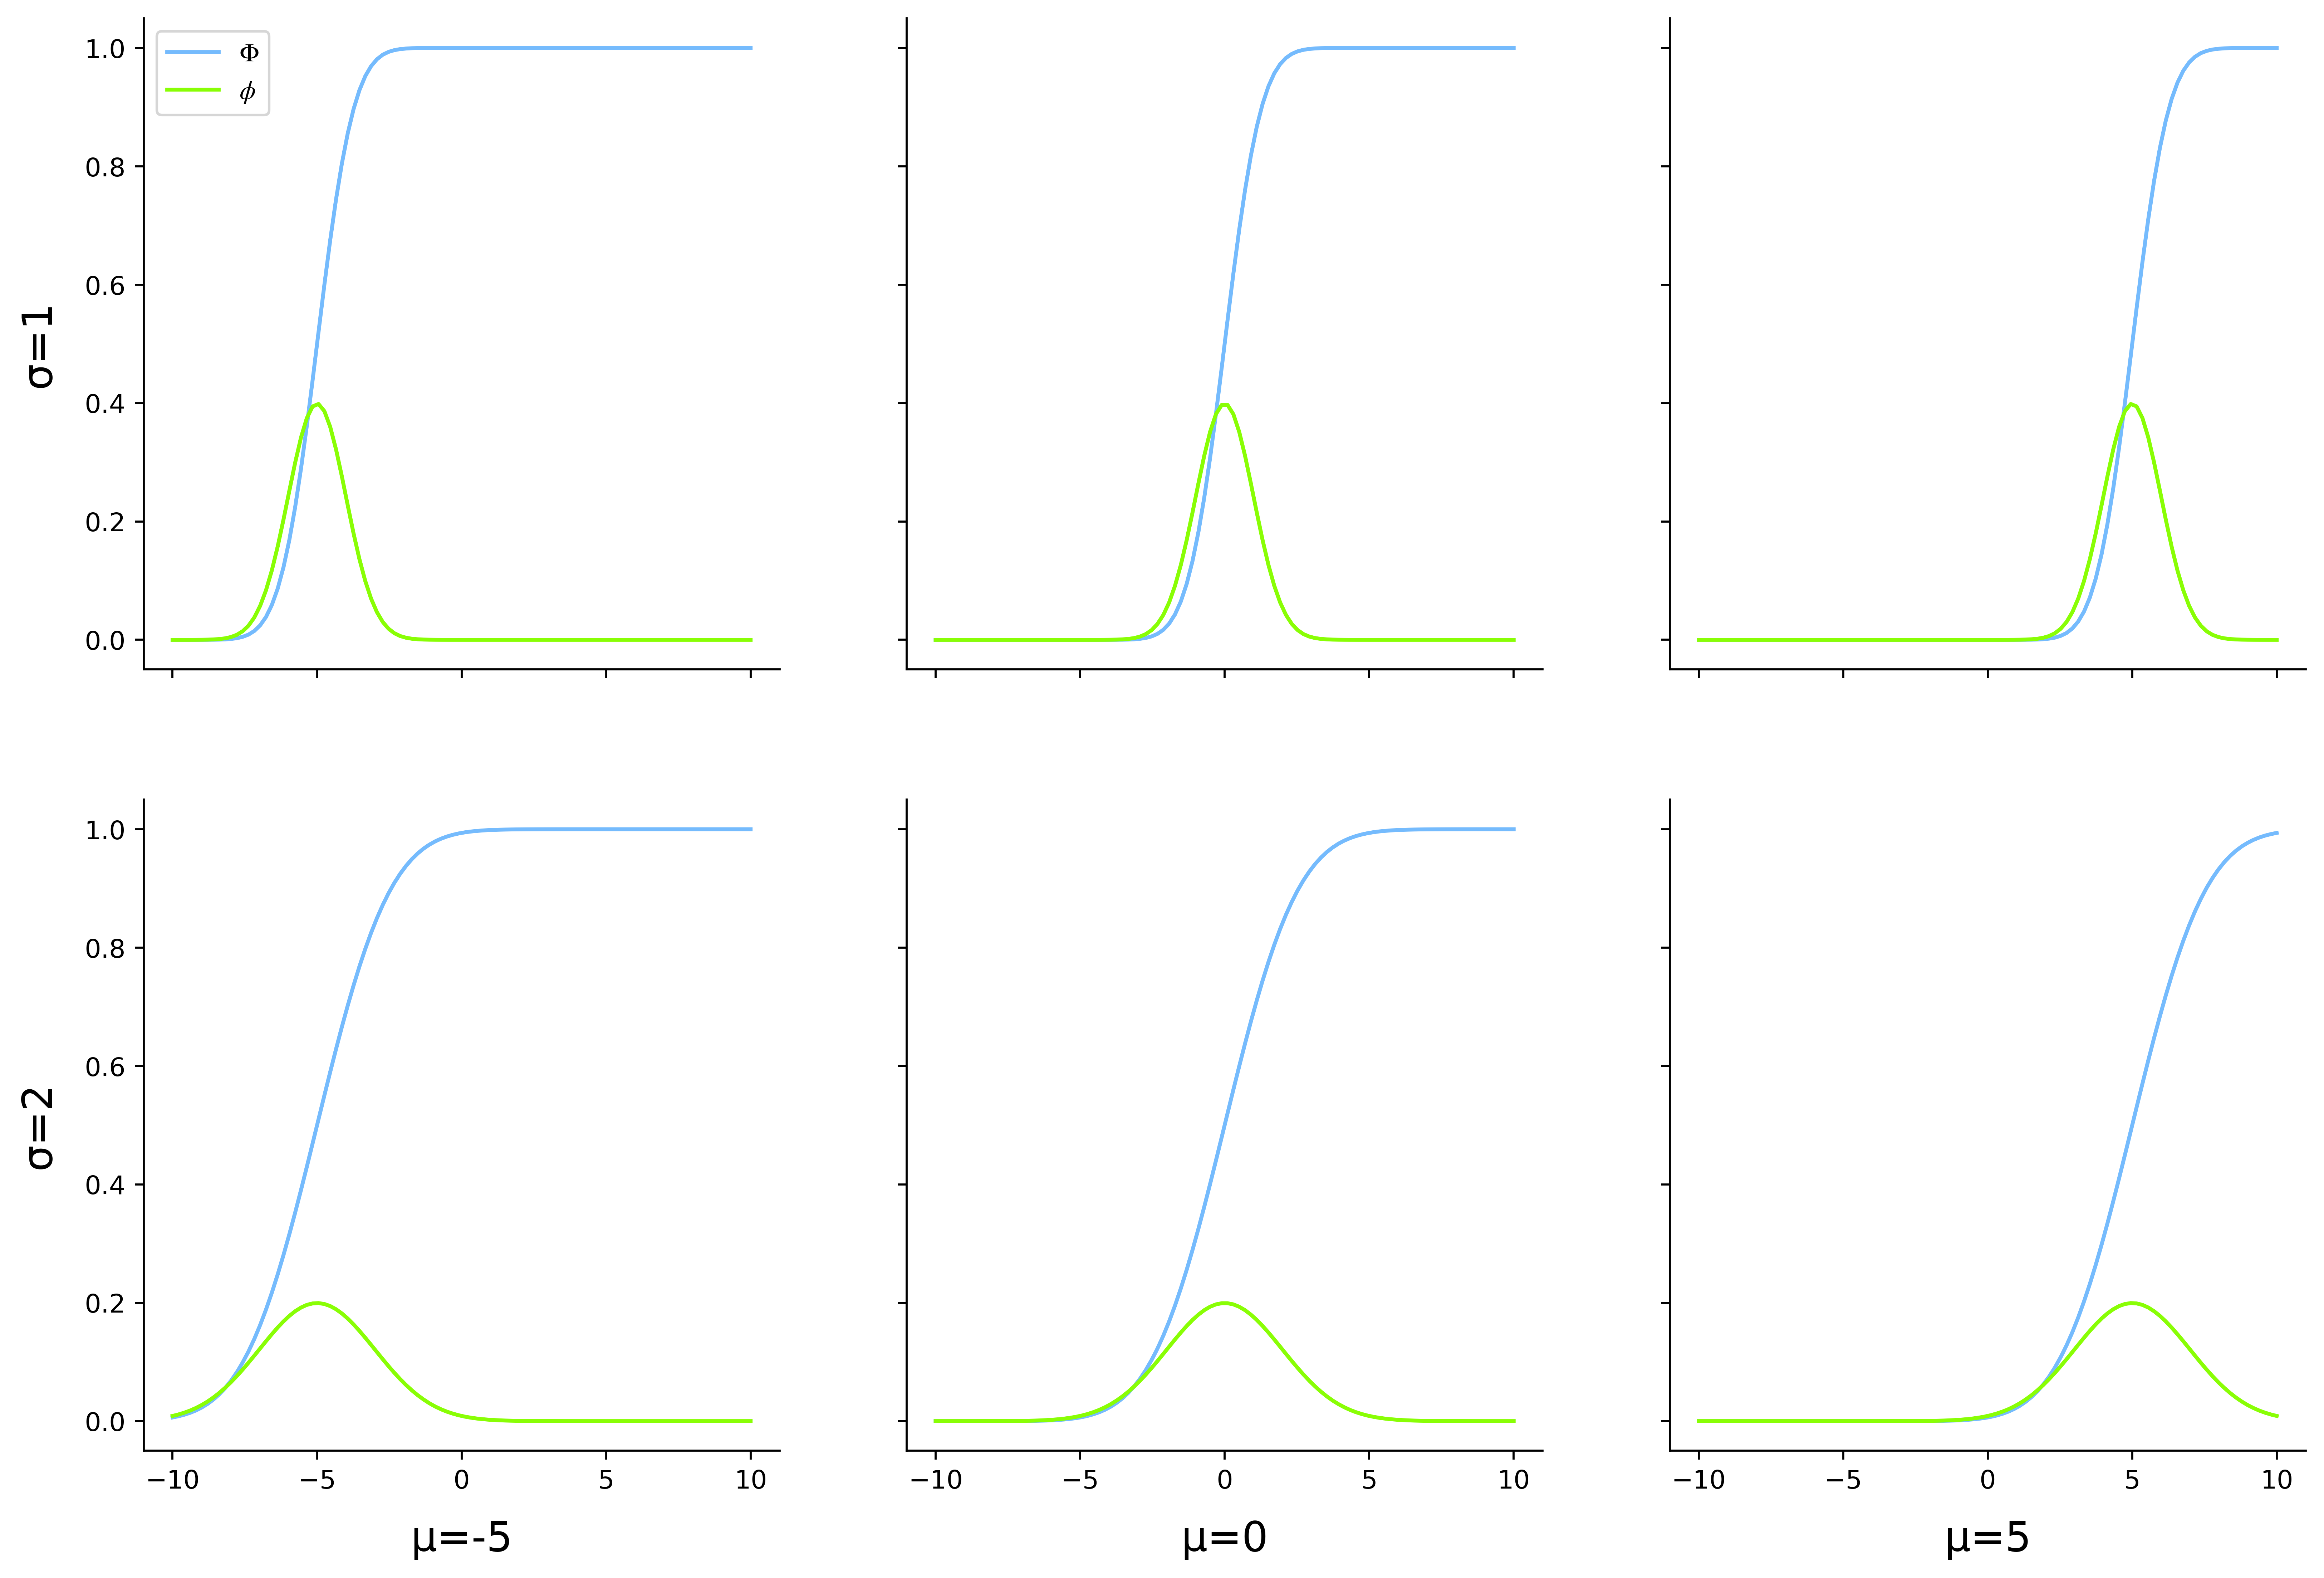

In [10]:
def normal_pdf(x, mu, sigma):
    return std_normal_pdf((x - mu) / sigma) / sigma

def normal_cdf(x, mu, sigma):
    return std_normal_cdf((x - mu) / sigma)

mus = [-5, 0, 5]
sigmas = [1, 2]
params = [[(mu, sigma) for mu in mus] for sigma in sigmas]

x = np.linspace(-10, 10, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)

for r, (ax_row, param_row) in enumerate(zip(axes, params)):
    for c, (ax, (mu, sigma)) in enumerate(zip(ax_row, param_row)):
        pdf_values = normal_pdf(x, mu, sigma)
        cdf_values = normal_cdf(x, mu, sigma)
        ax.plot(x, cdf_values, label=r'$\Phi$')
        ax.plot(x, pdf_values, label=r'$\phi$')
        if r == 1:
            ax.set_xlabel(f'µ={mu}')
        if c == 0:
            ax.set_ylabel(f'σ={sigma}')
        if r == 0 and c == 0:
            ax.legend()

glue("normal-graphs", fig, display=False)

```{glue:figure} normal-graphs
:name: fig:normal-graphs

Grafici delle funzioni di densità di probabilità (in verde) e di ripartizione
(in blu) di differenti distribuzioni norali. Gli assi delle ascisse e delle
ordinate indicano rispettivamente i valori dei parametri $\mu$ e $\sigma$.
```

Va notato che anche il calcolo della ripartizione di una generica
distribuzione normale richiede di valutare un integrale di cui non si
conosce la forma analitica, ma applicando {eq}`eq-normal-standardization`
è possibile ottenerne i valori a partire dalla tabulazione di $\Phi$.
Chiaramente, questo aspetto cade in secondo piano per tutte le applicazioni
nelle quali è possibile utilizzare un computer. 

```{figure} https://upload.wikimedia.org/wikipedia/commons/thumb/3/33/Bendixen_-_Carl_Friedrich_Gau%C3%9F%2C_1828.jpg/211px-Bendixen_-_Carl_Friedrich_Gau%C3%9F%2C_1828.jpg
---
figclass: margin
name: fig:gauss
width: 200px
align: left
---
Ritratto di Carl Friedrich Gauss a 50 anni, esseguito da Siegfried Detlev
Bendixen (immagine di pubblico dominio).
```
````{admonition} Nomenclatura
:class: naming

Nella letteratura si usano gli aggettivi _normale_ e
_gaussiano_ in modo quasi sempre intercambiabile, così che alcuni testi
parlano di distribuzioni normali e normali standard, variabili aleatorie
normali, densità normali e così via, mentre in altre fonti si trovano le
diciture «distribuzione gaussiana» o «gaussiana standard», «variabile
aleatoria gaussiana», «densità gaussiana» eccetera. In alcuni casi viene fatta
però una rilevante differenziazione (che questo testo non adotta), definendo
come _distribuzione normale_ quella che qui ho chiamato «distribuzione normale
standard» e usando l'aggettivo «gaussiana» per riferirsi in generale a questo
tipo di distribuzione. In altre parole, in questi testi la distribuzione
normale è un tipo specifico di distribuzione gaussiana, e precisamente quella
con media nulla e deviazione standard unitaria.

Il termine _gaussiano_ fa riferimento a Carl Friedrich Gauss (di cui la
{numref}`Figura %s <fig:gauss>` mostra un ritratto), una delle figure più
eminenti nella storia della matematica. All'inizio del 1800 Gauss dimostrò,
tra le altre cose, che la forma analitica della densità normale era l'unica
che permettesse di risolvere un particolare problema (quello della stima della
centralità in una popolazione, che affronteremo nel
{numref}`Paragrafo %s <sec:media-campionaria>`), e osservò come questa
distribuzione fosse in accordo con gli errori di predizione in ambito
astronomico. La paternità di questa distribuzione spetta però, come spesso
accade, a più studiosi: in particolare, le prime osservazioni sul
comportamento della distribuzione binomiale al crescere del parametro $n$ sono
state fatte da Abraham de Moivre nella prima metà del 1700, e Pierre-Simon
de Laplace ha sviluppato queste osservazioni verso la fine dello stesso
secolo, approssimando l'errore compiuto nel sostituire una distribuzione
binomiale con una gaussiana e calcolando

```{math}
\int_{-\infty}^{+\infty} \mathrm e^{-x^2} \; \mathrm d x = \sqrt{\pi} \enspace.
```

Sebbene venga fatto risalire sempre a Gauss, l'aggettivo _normale_ è stato
utilizzanto estensivamente dai matematici per riferirsi alla distribuzione
gaussiana solo a partire dal 1900.
````


Non è un caso che l'aggettivo _normale_ sia stato usato per definire i dati
per le cui frequenze vale  la regola empirica introdotta nel
{numref}`Paragrafo %s<sec:simmetria-e-normalita>`. Le percentuali indicate da
questa regola, in effetti, corrispondono esattamente alla probabilità di
osservare un valore della distribuzione normale standard che dista dal suo
valore atteso al più una, due o tre deviazioni standard, rispettivamente.

In [11]:
def prob_within_std(s):
    return normal_cdf(s, 0, 1) - normal_cdf(-s, 0, 1)

for s in np.arange(1, 4):
    print(f'sigma={s}, p={prob_within_std(s):.3f}')

sigma=1, p=0.683
sigma=2, p=0.954
sigma=3, p=0.997


Le distribuzioni normali godono di una serie di interessanti proprietà,
descritte di seguito.

````{prf:theorem}
:label: theo-normal

Siano $X \sim \mathrm N(\mu_X, \sigma_X)$, $Y \sim \mathrm N(\mu_Y, \sigma_Y)$
e $a, b \in \mathbb R$.

1. Definita $Y \coloneqq a X + b$, si ha
   $Y \sim \mathrm N(a \mu_X + b, a \sigma_X)$.
2. Definita $Z \coloneqq X + Y$,
   vale $Z \sim \mathrm N \left(\mu_X + \mu_Y, \sqrt{\sigma_X^2 + \sigma_Y^2}
   \right)$.

```{prf:proof}
Per quanto riguarda la prima parte, vale

\begin{equation*}
F_Y(x) = \mathbb P(Y \leq x) = \mathbb P \left(X \leq \frac{x-b}{a} \right)
       = F_X \left( \frac{x-b}{a} \right) \enspace,
\end{equation*}

e pertanto

\begin{equation*}
f_Y(x) = \frac{1}{a} f_X \left( \frac{x-b}{a} \right)
       = \frac{1}{\sqrt{2\pi} a \sigma_X}
         \mathrm e^{-\left( \frac{x - b}{a} - \mu_X \right)^2 / (2 \sigma_X^2)}
       = \frac{1}{\sqrt{2\pi} a \sigma_X}
         \mathrm e^{-\frac{(x - (a\mu_X + b))^2}{2 a^2 \sigma_X^2}} \enspace,
\end{equation*}

che implica la tesi. La seconda parte è dimostrata nel
{numref}`Paragrafo opzionale %s <sec:norm-fgm>`.

```
````

Da questo teorema si ricava un risultato che sarà particolarmente utile
nella parte di questo libro dedicata alla statistica inferenziale.

````{prf:corollary}
:label: cor:normal

Siano $X_1, \dots, X_n$ delle variabili aleatorie indipendenti, dove per ogni
$i = 1, \dots, n$ si ha $X_i \sim \mathrm N(\mu_i, \sigma_i)$. Dati
$a_1, \dots, a_n, b \in \mathbb R$ e definita

```{math}
Y \coloneqq \sum_{i=1}^n a_i X_i + b \enspace,
```

$Y$ è distribuita secondo una legge normale con valore atteso

```{math}
\mu_Y = \sum_{i=1}^n a_i + b
```

e deviazione standard

```{math}
\sigma_Y = \sqrt{\sum_{i=1}^n a_i^2 \sigma_i^2} \enspace.
```

```{prf:proof}
Segue per induzione dal {prf:ref}`theo-normal`.
```

````

(sec:norm-fgm)=
## Momenti della distribuzione normale (*)

Calcolare la funzione generatrice dei momenti per la distribuzione normale
richiede un po' di perizia. Partendo dalla definizione e ponendo
$X \sim \mathrm N(\mu, \sigma)$, si ha

```{margin}
La notazione $\mathrm{exp}(x) \coloneqq \mathrm e^x$ serve per
evitare, nel seguito, di usare gli apici per scrivere degli esponenti
complicati che risulterebbero difficili da leggere. 
```
\begin{align*}
m_X(t) &= \mathbb E(\mathrm e^{tX})
        = \int_{-\infty}^{+\infty}\frac{1}{\sqrt{2\pi} \sigma} \mathrm{exp}(tx)
          \mathrm{exp}\left( -\frac{(x - \mu)^2}{2 \sigma^2} \right)
          \; \mathrm dx \\
       &= \mathrm e^{t\mu}
          \int_{-\infty}^{+\infty}\frac{1}{\sqrt{2\pi} \sigma}
          \mathrm{exp}(t(x - \mu))
          \mathrm{exp}\left( -\frac{(x - \mu)^2}{2 \sigma^2} \right)
          \; \mathrm dx \enspace.
\end{align*}

Sfruttando le proprietà
delle potenze è possibile scrivere

\begin{align*}
m_X(t) &= \mathrm e^{t\mu}\int_{-\infty}^{+\infty}\frac{1}{\sqrt{2\pi} \sigma}
          \mathrm{exp}\left(t(x-\mu) -\frac{(x - \mu)^2}{2 \sigma^2} \right)
          \; \mathrm dx \\
       &= \mathrm e^{t\mu}\int_{-\infty}^{+\infty}\frac{1}{\sqrt{2\pi} \sigma}
          \mathrm{exp}\left(-\frac{1}{2 \sigma^2}
                        \left((x - \mu)^2 -2\sigma^2 t (x - \mu)
                        \right)
                      \right) \mathrm dx \enspace,
\end{align*}

così che nell'esponente all'interno dell'integrale è possibile completare
lo sviluppo di un quadrato nel modo seguente:

```{margin}
L'ultimo integrale in questa catena di equazioni è uguale a $1$ perché
l'integranda è la funzione di densità di probabilità di una distribuzione
normale di parametri $\mu + \sigma^2 t$ e $\sigma$.
```
\begin{align*}
m_X(t) &= \mathrm e^{t\mu}\int_{-\infty}^{+\infty}\frac{1}{\sqrt{2\pi} \sigma}
          \mathrm{exp}\left(-\frac{1}{2 \sigma^2}
                        \left((x - \mu)^2 -2\sigma^2 t (x - \mu)
                        \pm \sigma^4 t^2\right)
                      \right) \mathrm dx \\
       &= \mathrm e^{t\mu+\frac{1}{2}\sigma^2t^2}
          \underbrace{
            \int_{-\infty}^{+\infty}\frac{1}{\sqrt{2\pi} \sigma}
            \mathrm{exp}\left(-\frac{(x - \mu - \sigma^2 t)^2}{2 \sigma^2}
                        \right) \mathrm dx
          }_{=1}
        = \mathrm e^{t\mu+\frac{1}{2}\sigma^2t^2} \enspace.
         
\end{align*}

Il valore atteso di $X$ sarà dunque

```{math}
\mathbb E(X) = m_X'(0) = \left(
           \mathrm e^{t\mu+\frac{1}{2}\sigma^2t^2} (\mu + t \sigma^2)
           \right)_{t = 0} = \mu \enspace,
```

e analogamente

```{math}
\mathbb E(X^2) = m_X''(0) = \left(
           \mathrm e^{t\mu+\frac{1}{2}\sigma^2t^2} \left(
              (\mu + t \sigma^2)^2 + \sigma^2 \right)
           \right)_{t = 0} = \mu^2 + \sigma^2 \enspace,
```

così che $\mathrm{Var}(X) = \mu^2 + \sigma^2 - \mu^2 = \sigma^2$. Ciò dimostra
che i due parametri della distribuzione di una variabile aleatoria normale
equivalgono rispettivamente al suo valore atteso e alla sua deviazione
standard, e in particolare che una variabile aleatoria normale standard ha
valore atteso nullo e deviazione standard e varianza unitarie. Si può
inoltre facilmente verificare che, essendo
$Y \coloneqq X - \mu \sim \mathrm N(0, \sigma)$ e $m_Y(t) = \mathrm e^
{\sigma^2 t^2 / 2}$, vale

\begin{align*}
m_Y'(t)            &=   t \sigma^2 \mathrm e^{\sigma^2 t^2 / 2} \enspace, \\
m_Y''(t)           &=   \sigma^2 (1 + \sigma^2 t^2)
                        \mathrm e^{\sigma^2 t^2 / 2} \enspace, \\
m_Y'''(t)          &=   t \sigma^4 (3 + \sigma^2 t^2)
                        \mathrm e^{\sigma^2 t^2 / 2} \enspace, \\
m_Y^\mathrm{(iv)}(t) &= \sigma^4
                        (3 + 4 \sigma^2 t^2 + 2 \sigma^2 t^3 + \sigma^4 t^4)
                        \mathrm e^{\sigma^2 t^2 / 2} \enspace,
\end{align*}

da cui si ricava che, come già sappiamo,

\begin{align*}
\mu_1 &= 0 \enspace, \\
\mu_2 &= \sigma^2 \enspace, \\
\mu_3 &= 0 \enspace, \\
\mu_4 &= 3 \sigma^4 \enspace,
\end{align*}

e dall'ultima relazione segue che la curtosi di una qualsiasi distribuzione
normale è uguale a $\mu_4 / \sigma^4 - 3 = 0$.

La funzione generatrice dei momenti permette di dimostrare facilmente
anche la seconda parte del {prf:ref}`cor:normal`, in quanto, date due
variabili aleatorie indipendenti $X \sim \mathrm N(\mu_X, \sigma_X)$ e
$Y \sim \mathrm N(\mu_Y, \sigma_Y)$ e posto $Z \coloneqq X + Y$ si ha

```{margin}
L'indipendenza di $X$ e $Y$ permette di scrivere il valore atteso del
prodotto $\mathrm e^{tX} \mathrm e^{tY}$ come il prodotto dei corrispondenti
valori attesi.
```
\begin{align*}
m_Z(t) &= \mathbb E\left(\mathrm e^{t(X + Y)}\right)
        = \mathbb E\left( \mathrm e^{tX} \mathrm e^{tY} \right)
        = \mathbb E\left(\mathrm e^{tX}\right)
          \mathbb E\left(\mathrm e^{tY}\right)
        = m_X(t) m_Y(t) \\
       &= \mathrm e^{t\mu_X + \frac{1}{2}\sigma_X^2 t^2}
          \mathrm e^{t\mu_Y + \frac{1}{2}\sigma_Y^2 t^2}
        = \mathrm e^{t(\mu_X + \mu_Y)
          + \frac{1}{2}(\sigma_X^2 + \sigma_Y^2) t^2} \enspace,
\end{align*}

che è la funzione generatrice dei momenti di una distribuzione che ha
$\mu_X + \mu_Y$ per valore atteso e $\sigma_X^2 + \sigma_Y^2$ per varianza.

(sec:teo-de-moivre-laplace)=
## Il teorema di de Moivre-Laplace (*)

Dimostrare in modo matematicamente impeccabile il
{prf:ref}`teo:demoivre-laplace` richiede alcune conoscenze avanzate che vanno
al di fuori dello scopo di questo volume. Di seguito riporto una dimostrazione
che, pur introducendo delle approssimazioni rilevanti, permette a chi è
interessato ad approfondire l'argomento di convincersi della validità di
questo teorema.

Consideriamo le variabili aleatorie $X_n$ e $Y_n$ definite nell'enunciato
del teorema: la relazione che le lega implica che la prima variabile assume
una specificazione $x \in \{0, \dots n\}$ se e solo se la seconda assume una
specificazione $y$ tale che

```{math}
:label: eq:dML-relation
x = np + y \sqrt{n p (1-p)} \enspace,
```

e ovviamente varrà

```{math}
\mathbb P(Y_n = y) = \mathbb P(X_n = x)
                   = \binom{n}{x} p^x (1 - p)^{n - x} \enspace.
```

```{margin}
L'approssimazione di Stirling $n! \approx \sqrt{2 \pi n} n^n \mathrm e^{-n}$
è tanto più accurata quanto $n$ è grande.
```
Applicando a questa formula l'approssimazione di Stirling per il fattoriale
si ottiene

\begin{align*}
\mathbb P(Y_n = y)
   &\approx \frac{\sqrt{2\pi n} n^n \mathrm e^{-n}}
                 {\sqrt{2 \pi x} x^x \mathrm e^{-x}
                  \sqrt{2 \pi (n-x)} (n-x)^{(n-x)} \mathrm e^{-(n-x)}}
            p^x (1 - p)^{n - x} \\
   &= \sqrt{\frac{n}{2 \pi x (n-x)}} \frac{n^x n^{n-x}}{x^x (n-x)^{n-x}}
      p^x (1 - p)^{n - x} \\
   &= \sqrt{\frac{n}{2 \pi x (n-x)}}
      \left( \frac{np}{x} \right)^x
      \left( \frac{n(1-p)}{n-x} \right)^{n-x} \\
   &= \sqrt{\frac{n}{2 \pi x (n-x)}}
      \mathrm{exp}\left(
                  \underbrace{-x \ln \frac{x}{np}}_A
                  + \underbrace{(x - n) \ln \frac{n-x}{n(1-p)}}_B
                  \right) \enspace,
\end{align*}

dove l'ultimo passaggio è stato ottenuto elevando il prodotto esterno alla
radice quadrata al suo logaritmo naturale e sfruttando le proprietà dei
logaritmi. Semplifichiamo i conti che seguono tralasciando il fattore sotto
frazione e consideriamo separatamente i termini $A$ e $B$ che occorrono
all'esponente. Per quanto riguarda il primo, la relazione
{eq}`eq:dML-relation` implica

\begin{align*}
A &= -n p - y \sqrt{n p (1-p)} \ln \frac{np + y \sqrt{n p (1-p)}}{n p} \\
  &= -n p - y \sqrt{n p (1-p)} \ln \left( 1 + y \sqrt\frac{1 - p}{n p} \right)
     \enspace,
\end{align*}

così che considerando lo sviluppo di $\ln (1 + x)$ in serie di Taylor centrata
in $0$ e troncata al termine di secondo grado, ovvero
$\ln (1 + x) \approx x - \frac{x^2}{2}$, svolgendo i conti e trascurando
i termini di grado superiore al secondo possiamo ulteriormente semplificare
l'espressione in 

\begin{align*}
A &\approx -n p - y \sqrt{n p (1-p)}
   \left( y \sqrt\frac{1-p}{np} - \frac{y^2}{2} \frac{1-p}{np} \right) \\
  &= -y \sqrt{n p (1-p)} + \frac{y^2}{2} (1-p) - y^2 (1-p) \\
  &= -y \sqrt{n p (1-p)} - \frac{y^2}{2} (1-p) \enspace.
\end{align*}

Procedendo in modo analogo, $B$ si approssima nel modo seguente:

\begin{align*}
B &= \left( np + y \sqrt{n p (1-p)} - n \right)
     \ln \frac{n (1-p) - y \sqrt{n p (1-p)}}{n (1-p)} \\
  &= \left( np + y \sqrt{n p (1-p)} - n \right)
     \ln \left( 1 - y \sqrt\frac{p}{n (1-p)} \right) \\
  &\approx \left( np + y \sqrt{n p (1-p)} - n \right)
     \left( -y \sqrt\frac{p}{n (1-p)}
            - \frac{y^2}{2} \frac{p}{n (1-p)} \right) \\
  &= -\left( n (1-p) - y \sqrt{n p (1-p)} \right)
     \left( -y \sqrt\frac{p}{n (1-p)} 
            -\frac{y^2}{2} \frac{p}{n (1-p)} \right) \\
  &\approx y \sqrt{n p (1-p)} + \frac{y^2}{2} p - y^2 p \\
  &= y \sqrt{n p (1-p)} - \frac{y^2}{2} p \enspace.
\end{align*}

Pertanto, a meno del fattore che abbiamo trascurato,

```{math}
:label: eq:approx-dML

\mathbb P(Y_n = y) \approx \mathrm e^{-y^2/2} \enspace,
```

dove le approssimazioni
effettuate diventano più precise all'aumentare di $n$. Ora, per
$n \to +\infty$ possiamo approssimare la distribuzione di $Y_n$ con una
distribuzione continua, la cui densità si determina normalizzando il
secondo membro di {eq}`eq:approx-dML`, ovvero dividendolo per il valore

```{math}
I = \int_{-\infty}^{+\infty} \mathrm e^{-y^2/2} \; \mathrm d y \enspace.
```

Calcolare questo integrale in modo analitico richiede la conoscenza di
argomenti avanzati di analisi matematica, ma è possibile seguire il seguente
ragionamento informale. Abbiamo visto alcune argomentazioni che suggeriscono
che l'integrale di $\phi$ su $\mathbb R$ valga $1$. Possiamo rafforzare
questa intuizione ricorrendo all'approssimazione di questo integrale usando
le formule di quadratura.

In [12]:
quad(lambda u: 1/(2*np.pi)**0.5 * np.exp(-u**2 / 2), -np.inf, np.inf)

(0.9999999999999998, 1.017819139543109e-08)

Possiamo quindi ragionevolmente supporre che

```{math}
1 = \int_{-\infty}^{+\infty}
    \frac{1}{\sqrt{2\pi}} \mathrm e^{-y^2/2} \;\mathrm d y
  = \frac{1}{\sqrt{2\pi}} I \enspace,
```

e dunque ottenere la funzione di densità che approssima la distribuzione
di $Y_n$ per $n \to +\infty$ come

```{math}
f(y) = \frac{1}{\sqrt{2\pi}} \mathrm e^{-y^2/2} \enspace,
```

che coincide con la densità $\phi$ della distribuzione normale standard.


(sec:implementazione-modello-normale)=
## Implementazione del modello normale

La distribuzione normale è implementata in `scipy.stats` dalla funzione
`norm`, che restituisce un oggetto della classe che la libreria utilizza
per codificare le variabili casuali. Gli argomenti `loc` e `scale` permettono
di specificare, rispettivamente, valore atteso e deviazione standard della
distribuzione (ma è possibile omettere i nomi degli argomenti, a patto di
specificare prima il valore atteso e poi la deviazione standard).

A partire da un oggetto che descrive una distribuzione normale è possibile
invocare i metodi `pdf`, `cdf`, `ppf` e `rv` rispettivamente per calcolare la
funzione di densità di probabilità e di ripartizione, per estrarre i quantili
e per simulare l'estrazione di specificazioni.

[^calcolo-cdf-normale]: Vale la pena di sottolineare che $\phi$ è una funzione
continua e derivabile infinite volte, pertanto l'integrale che corrisponde a
$\Phi(x)$ esiste. Semplicemente, non è possibile esprimerlo in termini di
funzioni o operazioni matematiche note, a meno di non introdurre delle
_funzioni speciali_ che fondamentalmente incapsulano l'integrale
in questione. È questo il caso della cosiddetta _funzione degli errori_
(_error function_ nella terminologia inglese) definita da
$\mathrm{erf}(x) = \frac{2}{\sqrt{\pi}}
\int_0^x \mathrm e^{-u^2} \; \mathrm d u$;
ricorrendo a questa funzione è possibile scrivere
$\Phi(x) = \frac{1}{2} ( 1 + \mathrm{erf}(x/\sqrt{2}) )$.

[^approssimazione-integrali]: Uno dei modi più semplici di approssimare
numericamente il valore di un integrale di Riemann è quello di partizionare
l'intervallo di integrazione in un insieme di intervalli più piccoli e di
calcolare la somma delle aree dei rettangoli che hanno come base ognuno di
questi rettangoli e come altezza il valore che la funzione integranda assume
in un punto interno agli stessi, per esempio il punto medio. Il valore
ottenuto approssimerà sempre di più quello dell'integrale quando il numero
di intervalli cresce. La funzione `quad` che ho usato in questo paragrafo
adotta un approccio più sofisticato, applicando una _formula di
quadratura_ che, semplificando parecchio, consiste nel pesare i valori usati
per la funzione integranda e nello scegliere adattivamente il numero di
intervalli da considerare.

[^interpolazione-lineare]: Nel caso in cui sia necessario usare la tabella per
approssimare $\Phi$ per un argomento $x \in (x_0, x_1)$, dove gli estremi
dell'intervallo sono due valori tabulati successivi, tipicamente si
ricorre a un processo di _interpolazione lineare_: tenuto conto che la retta
che passa per i punti $(x_0, \Phi(x_0))$ e $(x_1, \Phi(x_1))$ ha equazione
$(y - \Phi(x_0)) / (\Phi(x_1)-\Phi(x_0)) = (x - x_0) / (x_1 - x_0)$,
possiamo usare il valore dell'ordinata di questa retta in corrispondenza di
$x$ come (ulteriore) approssimazione per $\Phi$, calcolando
$\Phi(x) \approx \Phi(x_0) + \left( \Phi(x_1) - \Phi(x_0) \right)
(x - x_0) / (x_1 - x_0)$.